<b> 2.	Starbucks Analysis

Problem Statement : Do an exploratory data analysis for the Starbuck Dataset with feature attributes that focuses on Food Menu and Drinks Menu considering the Nutrition Facts along. Wrap the analysis by subjecting favorable points with a final conclusion that ejects from the complete understanding


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# read the data into a pandas Dataframe object
df = pd.read_csv('starbucks-menu-nutrition-drinks.csv')
df2 = pd.read_csv('starbucks_drinkMenu_expanded.csv')
df3 = pd.read_csv('starbucks-menu-nutrition-food.csv', encoding = 'utf-16')

In [3]:
# to show number of rows and columns in csv file
df.shape

(177, 7)

In [4]:
# to show the top 5 rows of Datasets
df.head()

,Unnamed: 0,Calories,Fat (g),Carb. (g),Fiber (g),Protein,Sodium
0,Cool Lime Starbucks Refreshers™ Beverage,45,0,11,0,0,10
1,Ombré Pink Drink,-,-,-,-,-,-
2,Pink Drink,-,-,-,-,-,-
3,Strawberry Acai Starbucks Refreshers™ Beverage,80,0,18,1,0,10
4,Very Berry Hibiscus Starbucks Refreshers™ Beve...,60,0,14,1,0,10


In [5]:
# rename the column name
df.rename(columns ={'Unnamed: 0' : 'Beverages'},inplace = True)

In [6]:
# to show the changed column name
df.head(2)

,Beverages,Calories,Fat (g),Carb. (g),Fiber (g),Protein,Sodium
0,Cool Lime Starbucks Refreshers™ Beverage,45,0,11,0,0,10
1,Ombré Pink Drink,-,-,-,-,-,-


In [7]:
# to show the information of above Datasets
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Beverages  177 non-null    object
 1   Calories   177 non-null    object
 2   Fat (g)    177 non-null    object
 3   Carb. (g)  177 non-null    object
 4   Fiber (g)  177 non-null    object
 5   Protein    177 non-null    object
 6   Sodium     177 non-null    object
dtypes: object(7)
memory usage: 9.8+ KB


In [8]:
# to show the sum of null values
df.isnull().sum()

Beverages    0
Calories     0
Fat (g)      0
Carb. (g)    0
Fiber (g)    0
Protein      0
Sodium       0
dtype: int64

In [9]:
# replace values '-' to '0'
df.replace('-', 0, inplace = True)

In [10]:
#convert object datatype into float and integer
df["Calories"] = df["Calories"].astype(int)
df["Fat (g)"] = df["Fat (g)"].astype(float)
df["Carb. (g)"] = df["Carb. (g)"].astype(int)
df["Fiber (g)"] = df["Fiber (g)"].astype(int)
df["Protein"] = df["Protein"].astype(int)
df["Sodium"] = df["Sodium"].astype(int)

In [11]:
# to show the datatype
print(df.Calories.dtype)
print(df["Fat (g)"].dtype)
print(df["Carb. (g)"].dtype)
print(df["Fiber (g)"].dtype)
print(df.Protein.dtype)
print(df.Sodium.dtype)

int32
float64
int32
int32
int32
int32


In [12]:
# used describe() for object datatype
df.describe(include = 'object')

,Beverages
count,177
unique,154
top,Tazo® Bottled Organic Iced Black Tea
freq,2


In [13]:
# drop the duplicates values and storing the unique values in df1
sort = df.sort_values(by = 'Beverages', ascending = True)
df1 = sort.drop_duplicates(subset = 'Beverages')
# to show rows and columns
df1.shape

(154, 7)

In [14]:
# to show the object datatype after drop the duplicates value
df1.describe(include='object')

,Beverages
count,154
unique,154
top,Blonde Roast
freq,1


In [15]:
# Describbe function is used for calculating some statistical data like percentile, mean and std of the numerical value of the above Dataset
df1.describe()

,Calories,Fat (g),Carb. (g),Fiber (g),Protein,Sodium
count,154.000000,154.000000,154.000000,154.000000,154.000000,154.000000
mean,66.623377,1.301948,11.655844,0.266234,2.305195,31.136364
std,99.108581,3.182067,16.496139,1.114622,4.780582,59.468019
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,120.000000,0.000000,22.500000,0.000000,1.000000,13.750000
max,430.000000,26.000000,64.000000,8.000000,20.000000,240.000000


In [16]:
# to show the all column name
df1.columns

Index(['Beverages', 'Calories', 'Fat (g)', 'Carb. (g)', 'Fiber (g)', 'Protein',
       'Sodium'],
      dtype='object')

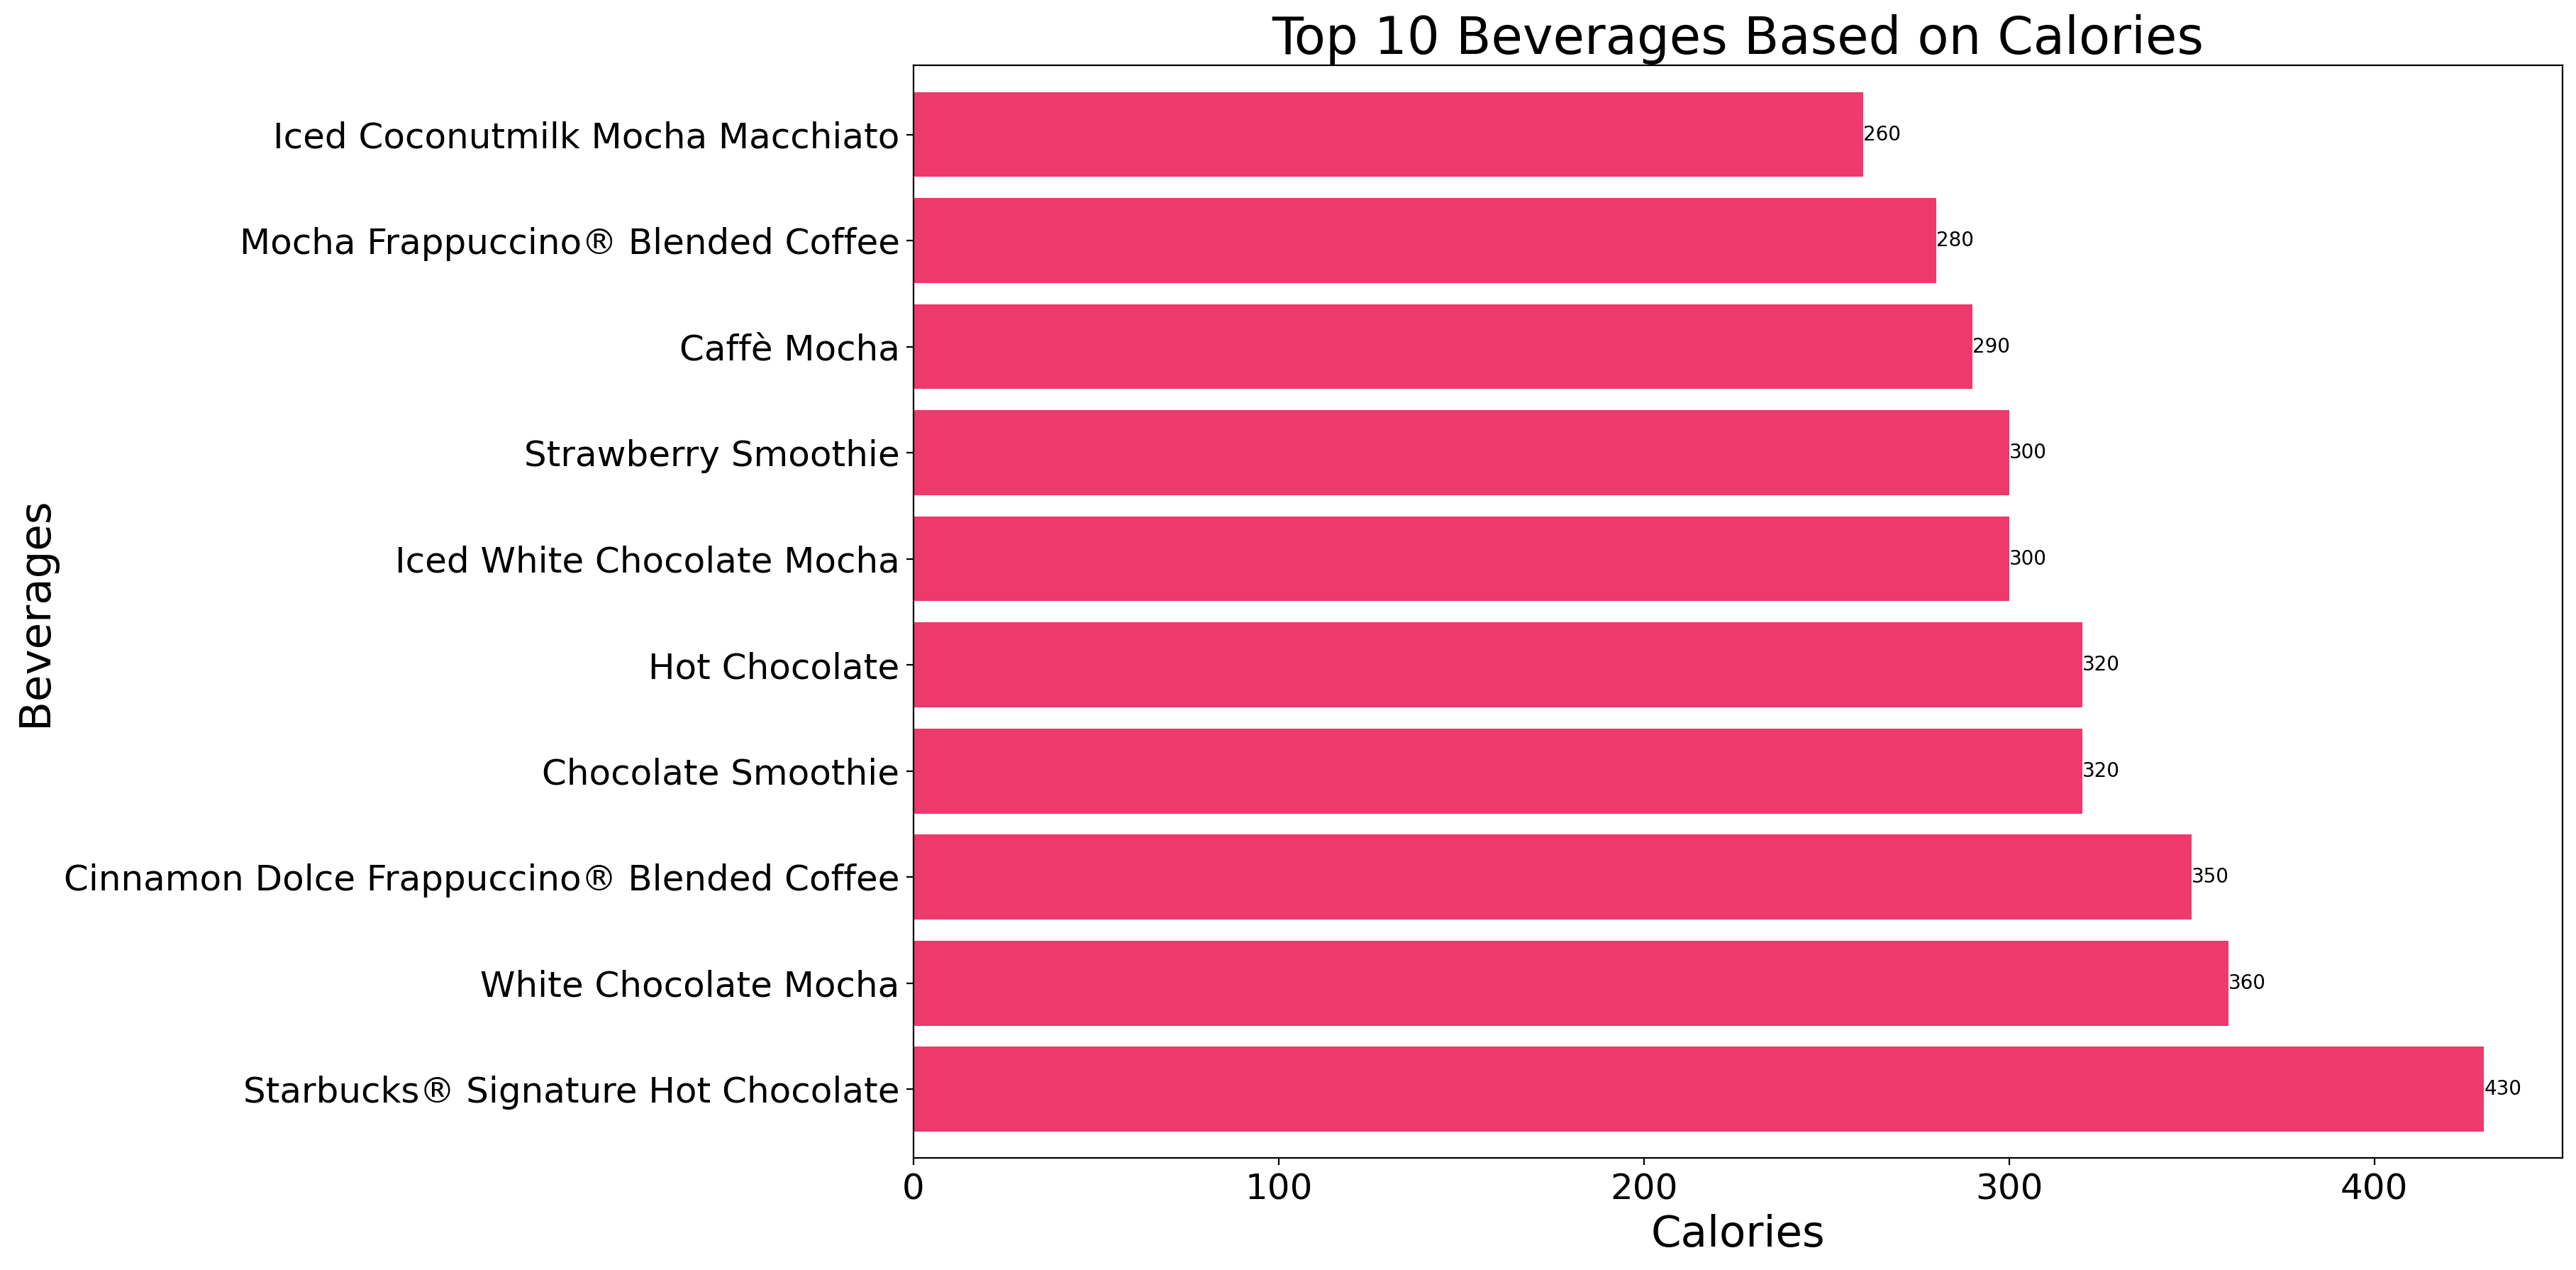

In [17]:
x = df1.groupby(['Beverages']).max()['Calories'].sort_values(ascending=False)[:10] 
plt.figure(figsize = (15,10), dpi = 200)
ax = x.plot(kind = 'barh', width = 0.8,color = '#ed396c' )
for bars in ax.containers :
    ax.bar_label(bars)
    
ax.set_xlabel('Calories', size = 22)    
ax.set_ylabel('Beverages', size = 22)    
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.title("Top 10 Beverages Based on Calories", size = 26)
plt.show()

<b> 'Starbucks Signature Hot Chocolate' is Highest in Calories which is 430

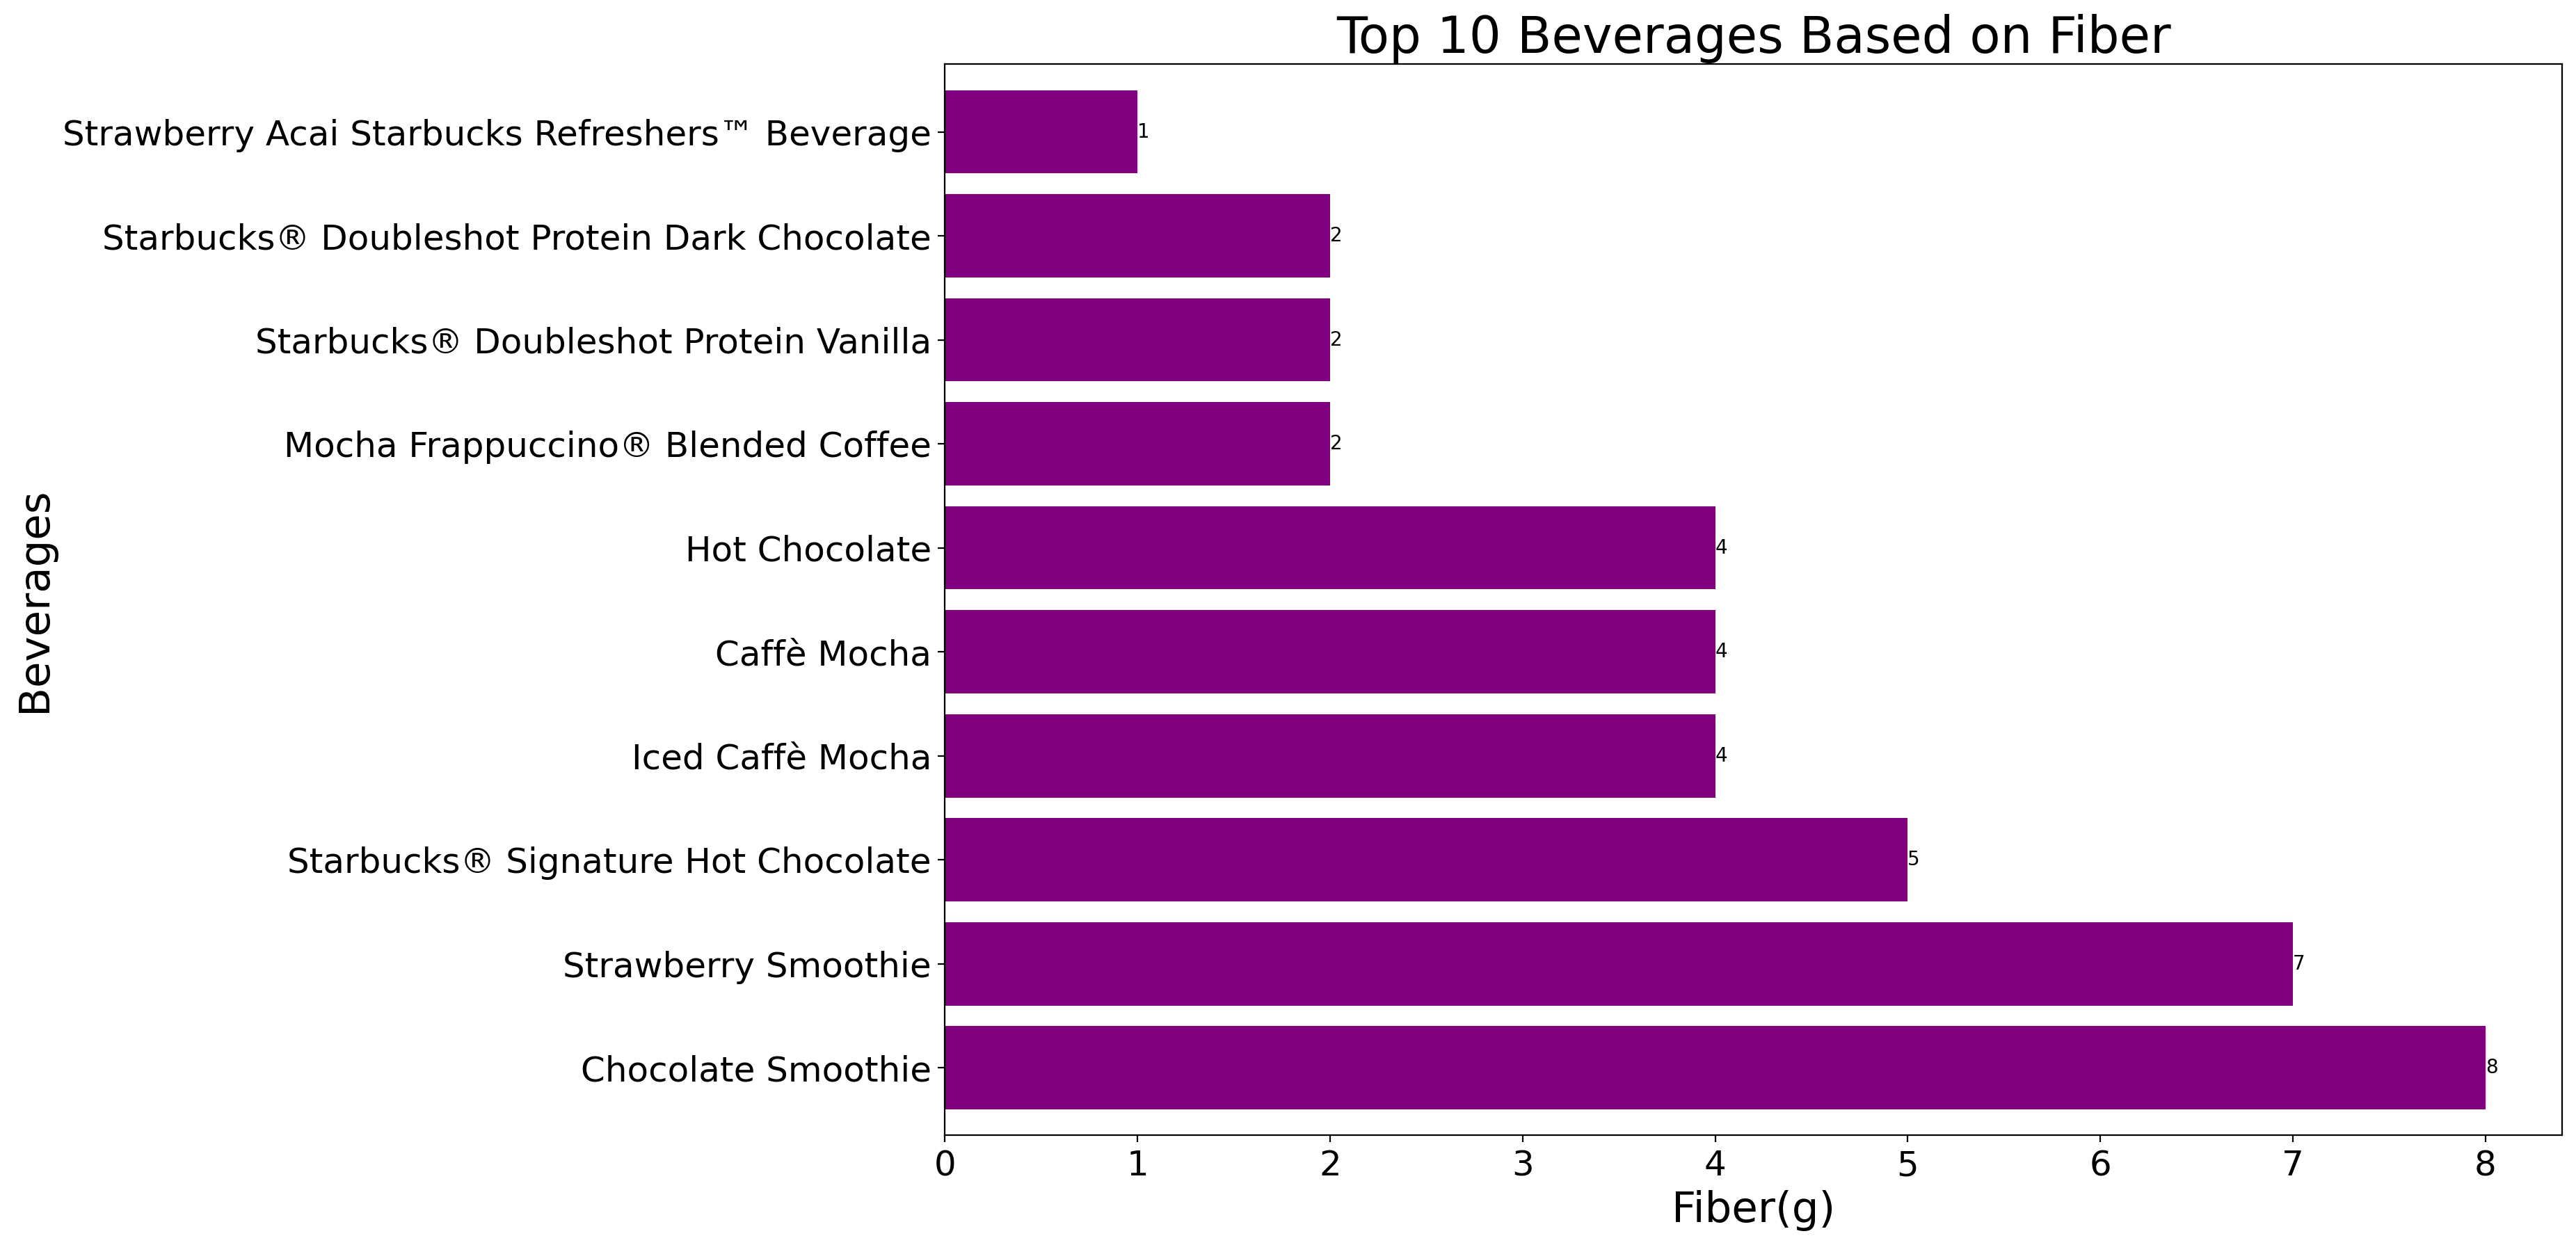

In [18]:
x = df1.groupby(['Beverages']).max()['Fiber (g)'].sort_values(ascending=False)[:10] 
plt.figure(figsize = (15,10), dpi = 200)
ax = x.plot(kind = 'barh', width = 0.8,color = 'purple' )
for bars in ax.containers :
    ax.bar_label(bars)
    
ax.set_xlabel('Fiber(g)', size = 22)    
ax.set_ylabel('Beverages', size = 22)    
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.title("Top 10 Beverages Based on Fiber", size = 26)
plt.show()

<b> 'Chocolate Smoothie' is Highest in Fibre which is 8g

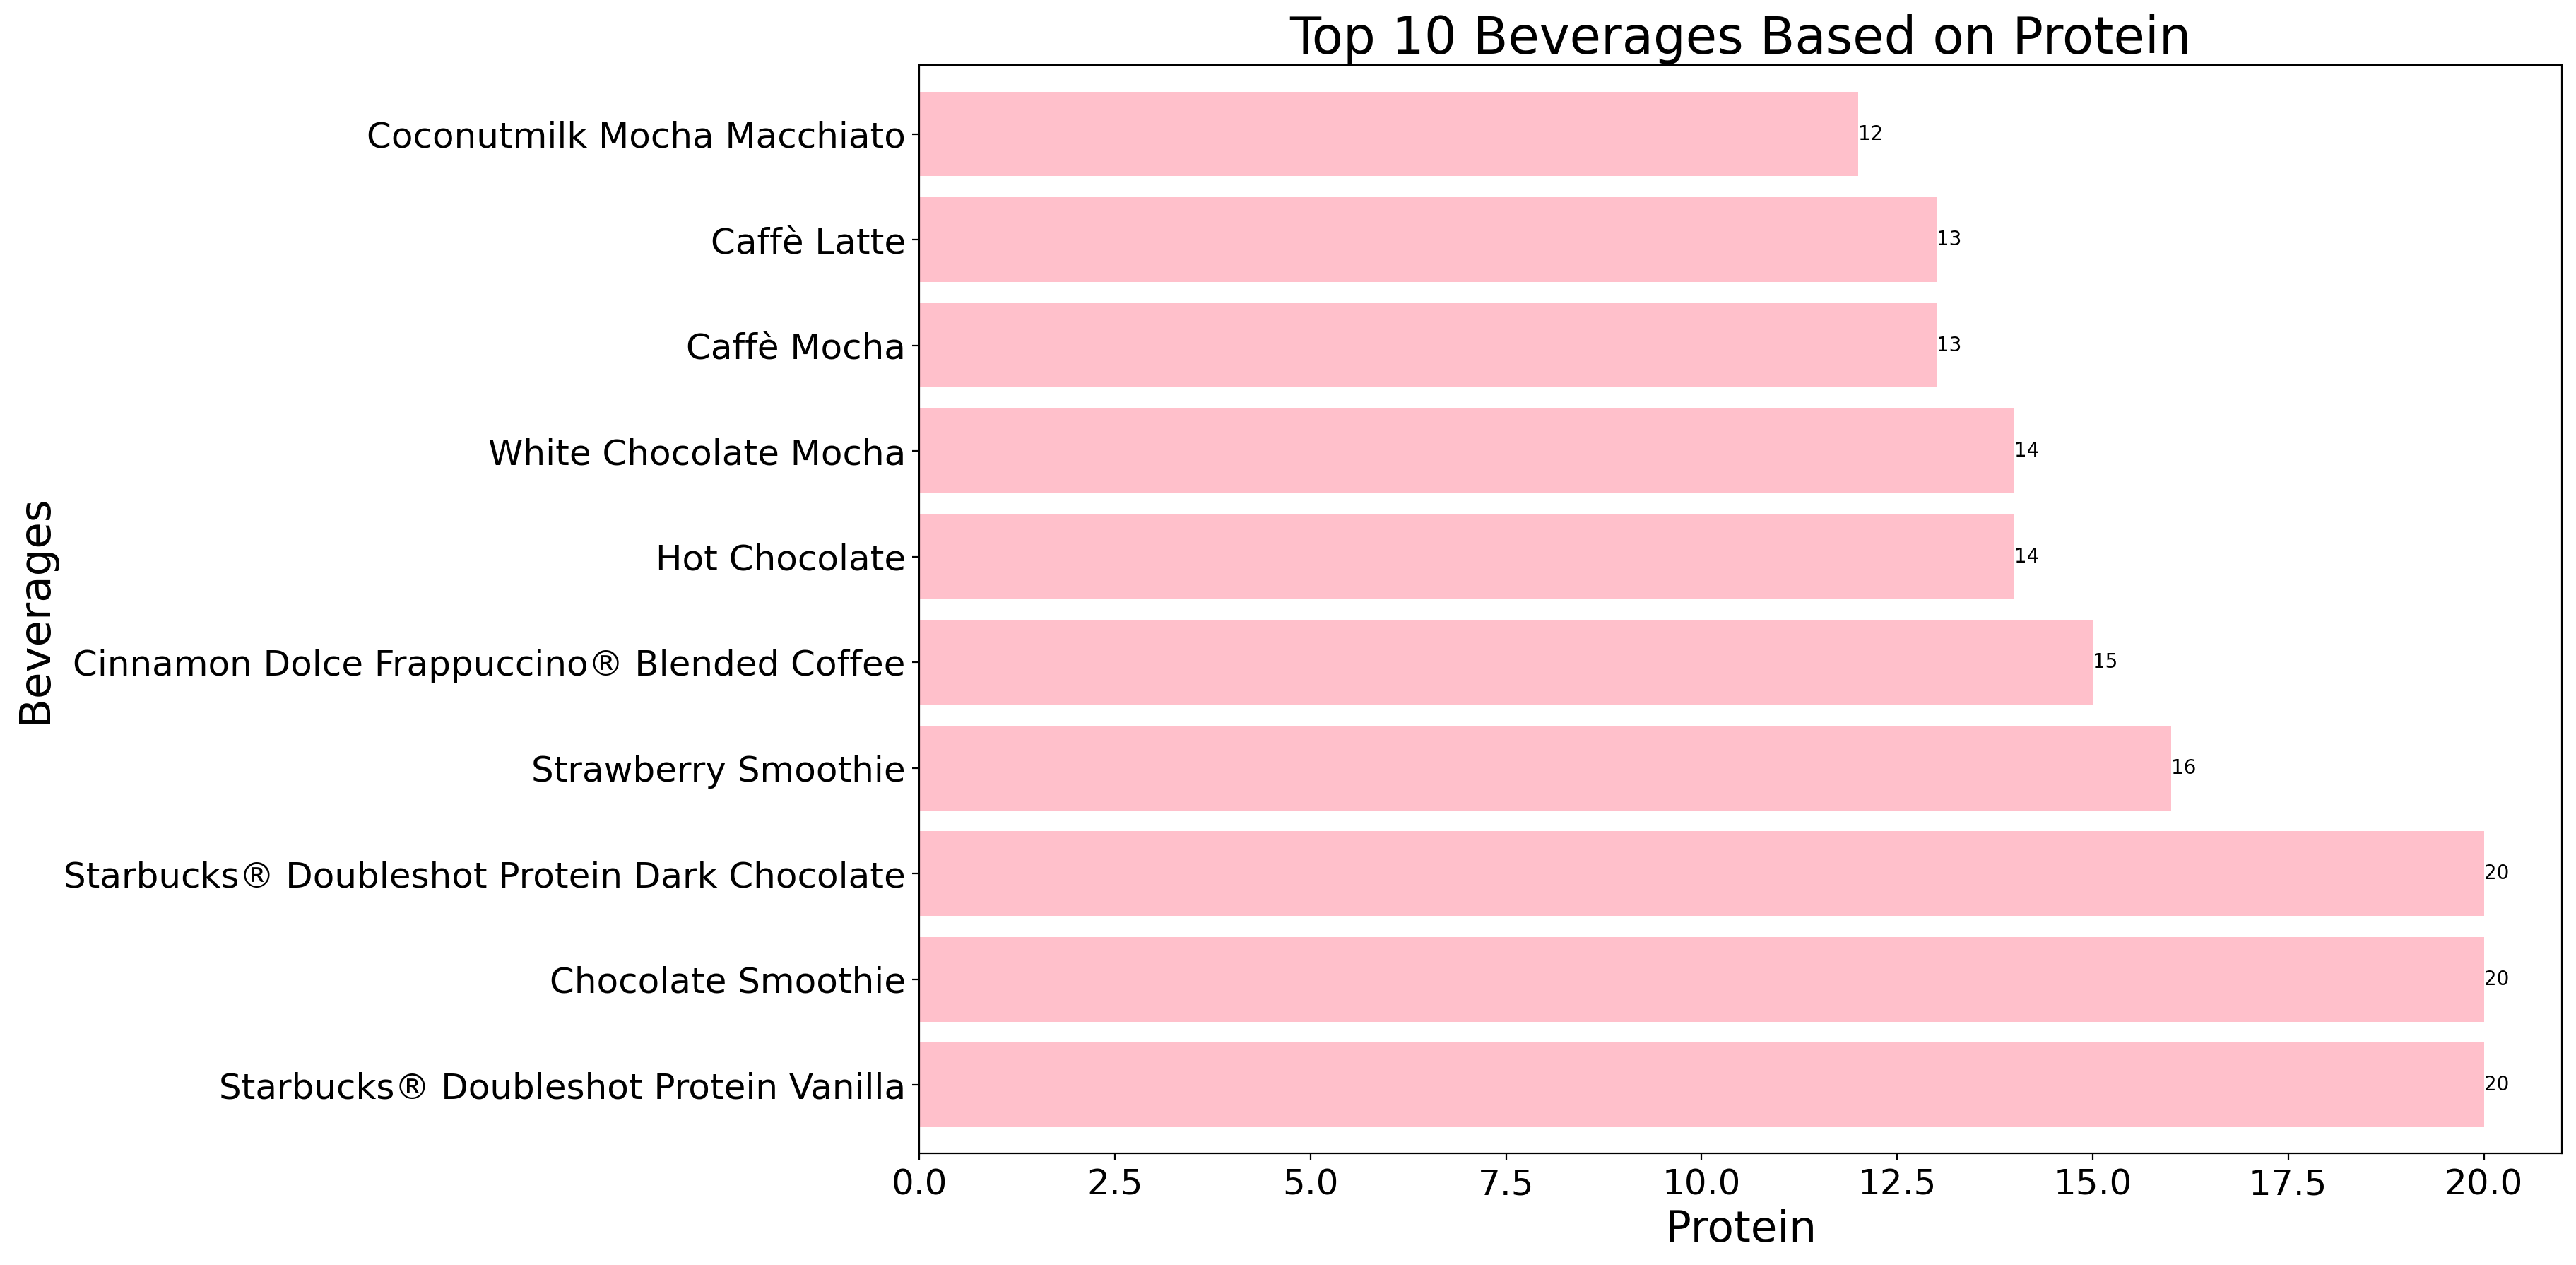

In [19]:
x = df1.groupby(['Beverages']).max()['Protein'].sort_values(ascending=False)[:10] 
plt.figure(figsize = (15,10), dpi = 200)
ax = x.plot(kind = 'barh', width = 0.8,color = 'pink' )
for bars in ax.containers :
    ax.bar_label(bars)
    
ax.set_xlabel('Protein', size = 22)    
ax.set_ylabel('Beverages', size = 22)    
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.title("Top 10 Beverages Based on Protein", size = 26)
plt.show()

<b> 'Starbucks Doubleshot Protein Vanilla' is Highest in Protein which is 20

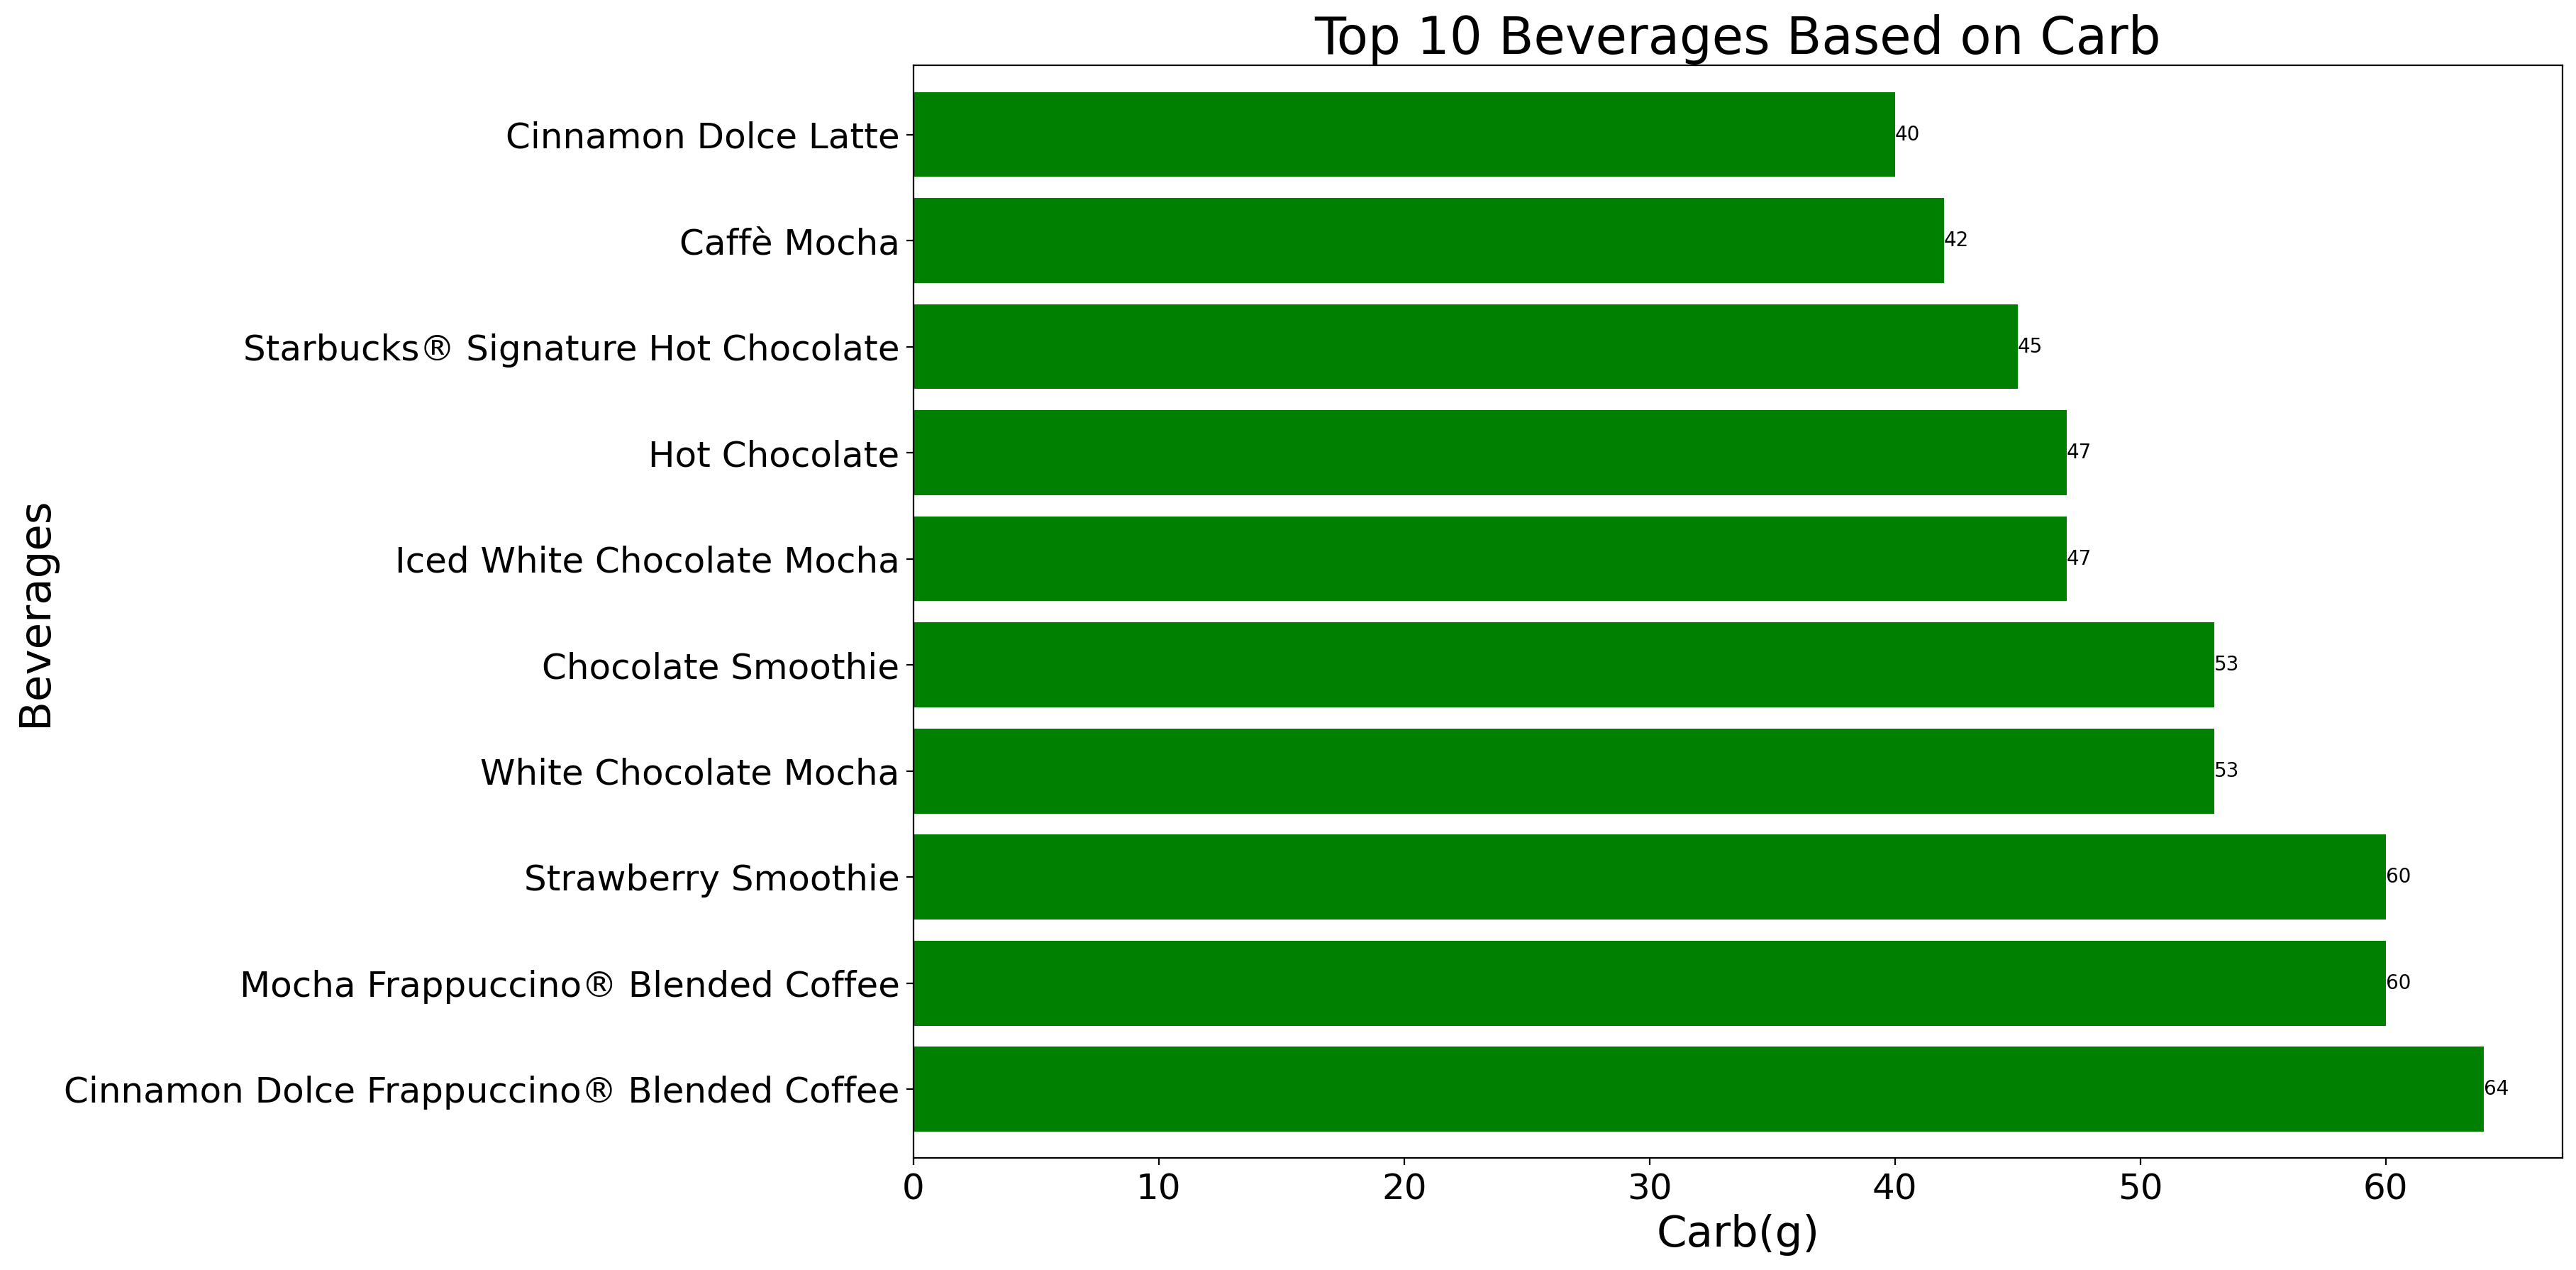

In [20]:
x = df1.groupby(['Beverages']).max()['Carb. (g)'].sort_values(ascending=False)[:10] 
plt.figure(figsize = (15,10), dpi = 200)
ax = x.plot(kind = 'barh', width = 0.8,color = 'g' )
for bars in ax.containers :
    ax.bar_label(bars)
    
ax.set_xlabel('Carb(g)', size = 22)    
ax.set_ylabel('Beverages', size = 22)    
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.title("Top 10 Beverages Based on Carb", size = 26)
plt.show()

<b> 'Cinnamon Dolce Frappuccino Blended Coffee' is Highest in Calories which is 64g

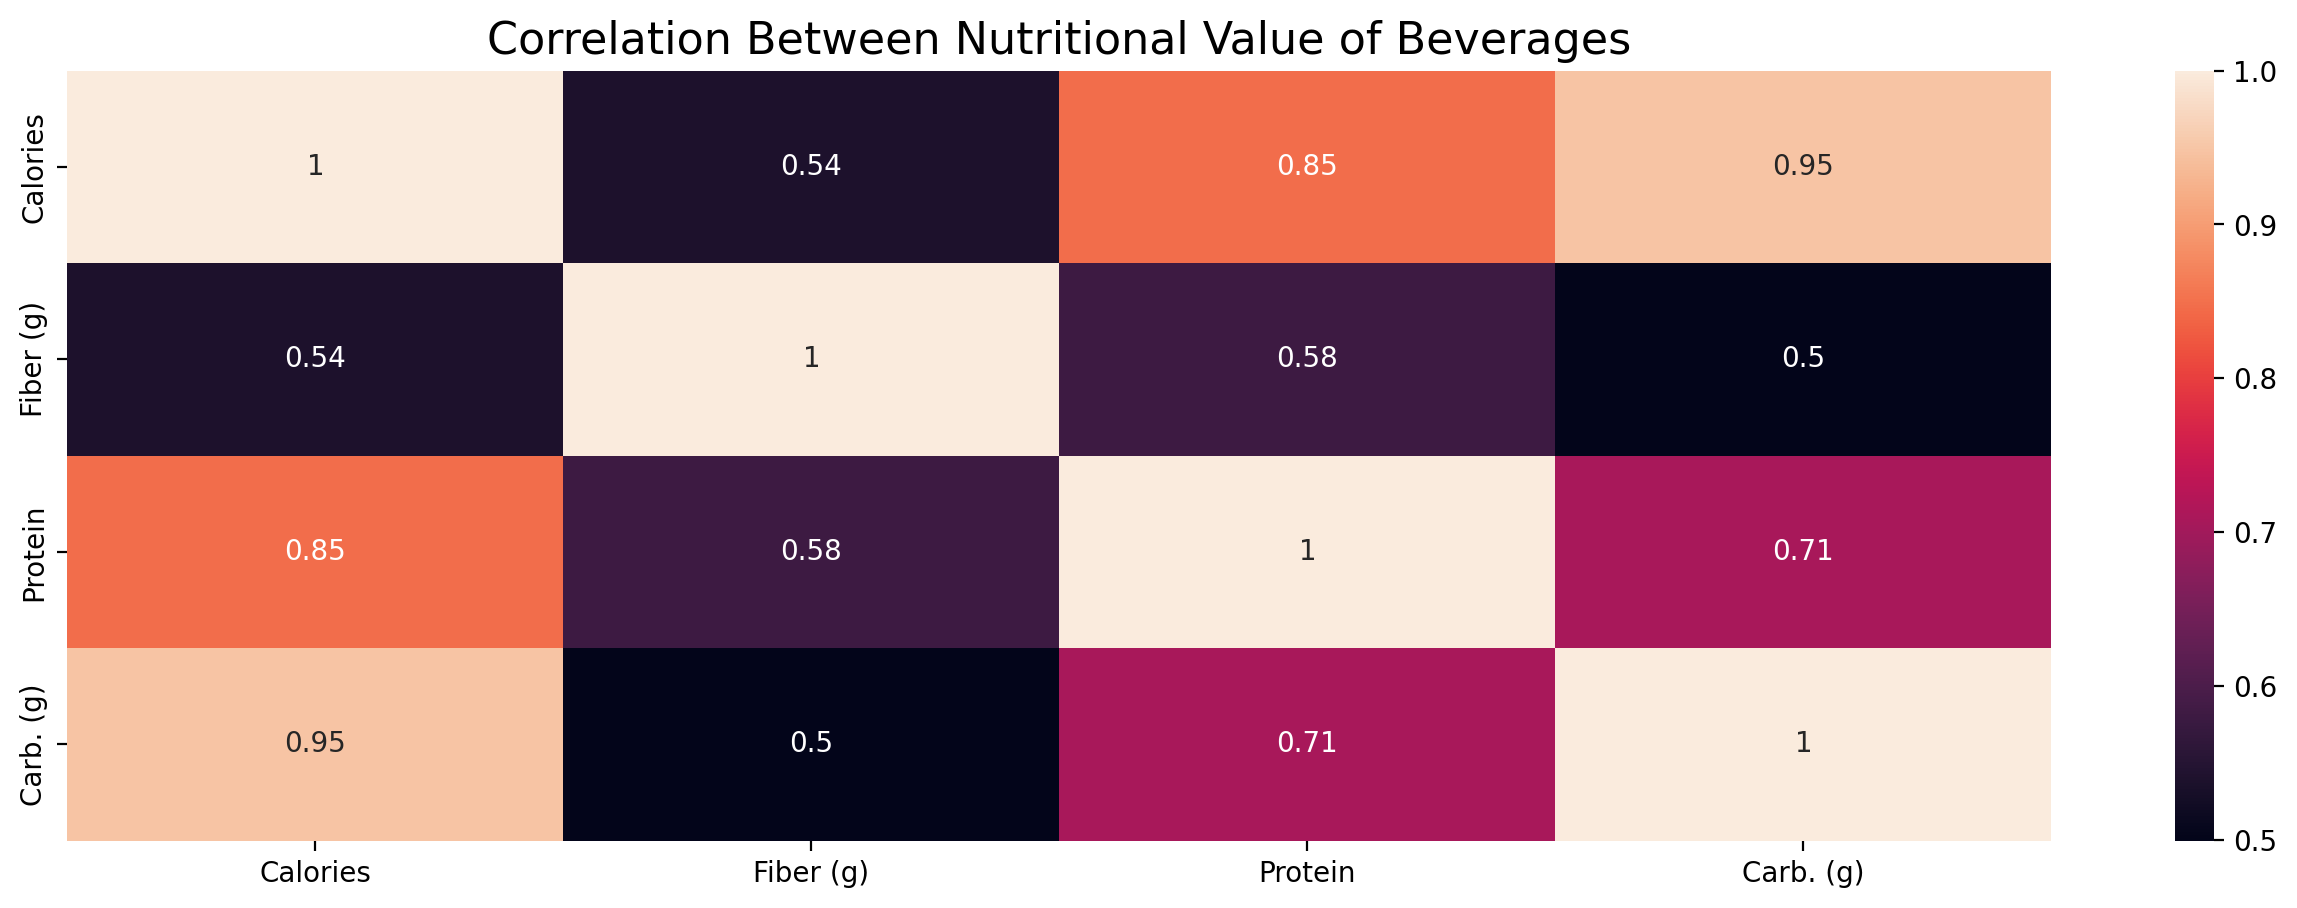

In [21]:
plt.figure(figsize = (16,5), dpi = 200)
sns.heatmap(df1[['Calories','Fiber (g)','Protein','Carb. (g)']].corr(), annot = True)
plt.title('Correlation Between Nutritional Value of Beverages', size = 16)
plt.show()

<b> In Heatmap shows, correlation between Calories, Fibre, Protein and Carb.

In [22]:
df2.shape

(242, 18)

In [23]:
df2.head()

,Beverage_category,Beverage,Beverage_prep,Calories,Total Fat (g),Trans Fat (g),Saturated Fat (g),Sodium (mg),Total Carbohydrates (g),Cholesterol (mg),Dietary Fibre (g),Sugars (g),Protein (g),Vitamin A (% DV),Vitamin C (% DV),Calcium (% DV),Iron (% DV),Caffeine (mg)
0,Coffee,Brewed Coffee,Short,3,0.1,0.0,0.0,0,5,0,0,0,0.3,0%,0%,0%,0%,175
1,Coffee,Brewed Coffee,Tall,4,0.1,0.0,0.0,0,10,0,0,0,0.5,0%,0%,0%,0%,260
2,Coffee,Brewed Coffee,Grande,5,0.1,0.0,0.0,0,10,0,0,0,1.0,0%,0%,0%,0%,330
3,Coffee,Brewed Coffee,Venti,5,0.1,0.0,0.0,0,10,0,0,0,1.0,0%,0%,2%,0%,410
4,Classic Espresso Drinks,Caffè Latte,Short Nonfat Milk,70,0.1,0.1,0.0,5,75,10,0,9,6.0,10%,0%,20%,0%,75


In [24]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Beverage_category          242 non-null    object 
 1   Beverage                   242 non-null    object 
 2   Beverage_prep              242 non-null    object 
 3   Calories                   242 non-null    int64  
 4    Total Fat (g)             242 non-null    object 
 5   Trans Fat (g)              242 non-null    float64
 6   Saturated Fat (g)          242 non-null    float64
 7    Sodium (mg)               242 non-null    int64  
 8    Total Carbohydrates (g)   242 non-null    int64  
 9   Cholesterol (mg)           242 non-null    int64  
 10   Dietary Fibre (g)         242 non-null    int64  
 11   Sugars (g)                242 non-null    int64  
 12   Protein (g)               242 non-null    float64
 13  Vitamin A (% DV)           242 non-null    object 

In [25]:
df2.duplicated().sum()

0

In [26]:
# replace values(Varies) replace to 0
df2.replace('Varies', 0, inplace = True)

In [27]:
  df2.isnull().sum()         

Beverage_category            0
Beverage                     0
Beverage_prep                0
Calories                     0
 Total Fat (g)               0
Trans Fat (g)                0
Saturated Fat (g)            0
 Sodium (mg)                 0
 Total Carbohydrates (g)     0
Cholesterol (mg)             0
 Dietary Fibre (g)           0
 Sugars (g)                  0
 Protein (g)                 0
Vitamin A (% DV)             0
Vitamin C (% DV)             0
 Calcium (% DV)              0
Iron (% DV)                  0
Caffeine (mg)                1
dtype: int64

In [28]:
df2['Caffeine (mg)'].fillna(0, inplace = True)

In [29]:
# used describe() for object datatype
df2.describe(include='object')

,Beverage_category,Beverage,Beverage_prep,Total Fat (g),Vitamin A (% DV),Vitamin C (% DV),Calcium (% DV),Iron (% DV),Caffeine (mg)
count,242,242,242,242,242,242,242,242,242
unique,9,33,13,24,11,10,14,18,36
top,Classic Espresso Drinks,Tazo® Full-Leaf Red Tea Latte (Vanilla Rooibos),Soymilk,0.1,10%,0%,10%,0%,75
freq,58,12,66,34,43,188,51,99,37


In [30]:
df2.describe()

,Calories,Trans Fat (g),Saturated Fat (g),Sodium (mg),Total Carbohydrates (g),Cholesterol (mg),Dietary Fibre (g),Sugars (g),Protein (g)
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000
mean,193.871901,1.307025,0.037603,6.363636,128.884298,35.991736,0.805785,32.962810,6.978512
std,102.863303,1.640259,0.071377,8.630257,82.303223,20.795186,1.445944,19.730199,4.871659
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,120.000000,0.100000,0.000000,0.000000,70.000000,21.000000,0.000000,18.000000,3.000000
50%,185.000000,0.500000,0.000000,5.000000,125.000000,34.000000,0.000000,32.000000,6.000000
75%,260.000000,2.000000,0.100000,10.000000,170.000000,50.750000,1.000000,43.750000,10.000000
max,510.000000,9.000000,0.300000,40.000000,340.000000,90.000000,8.000000,84.000000,20.000000


In [31]:
df2.columns

Index(['Beverage_category', 'Beverage', 'Beverage_prep', 'Calories',
       ' Total Fat (g)', 'Trans Fat (g) ', 'Saturated Fat (g)', ' Sodium (mg)',
       ' Total Carbohydrates (g) ', 'Cholesterol (mg)', ' Dietary Fibre (g)',
       ' Sugars (g)', ' Protein (g) ', 'Vitamin A (% DV) ', 'Vitamin C (% DV)',
       ' Calcium (% DV) ', 'Iron (% DV) ', 'Caffeine (mg)'],
      dtype='object')

In [32]:
df2['Beverage_category'].unique()

array(['Coffee', 'Classic Espresso Drinks', 'Signature Espresso Drinks',
       'Tazo® Tea Drinks', 'Shaken Iced Beverages', 'Smoothies',
       'Frappuccino® Blended Coffee', 'Frappuccino® Light Blended Coffee',
       'Frappuccino® Blended Crème'], dtype=object)

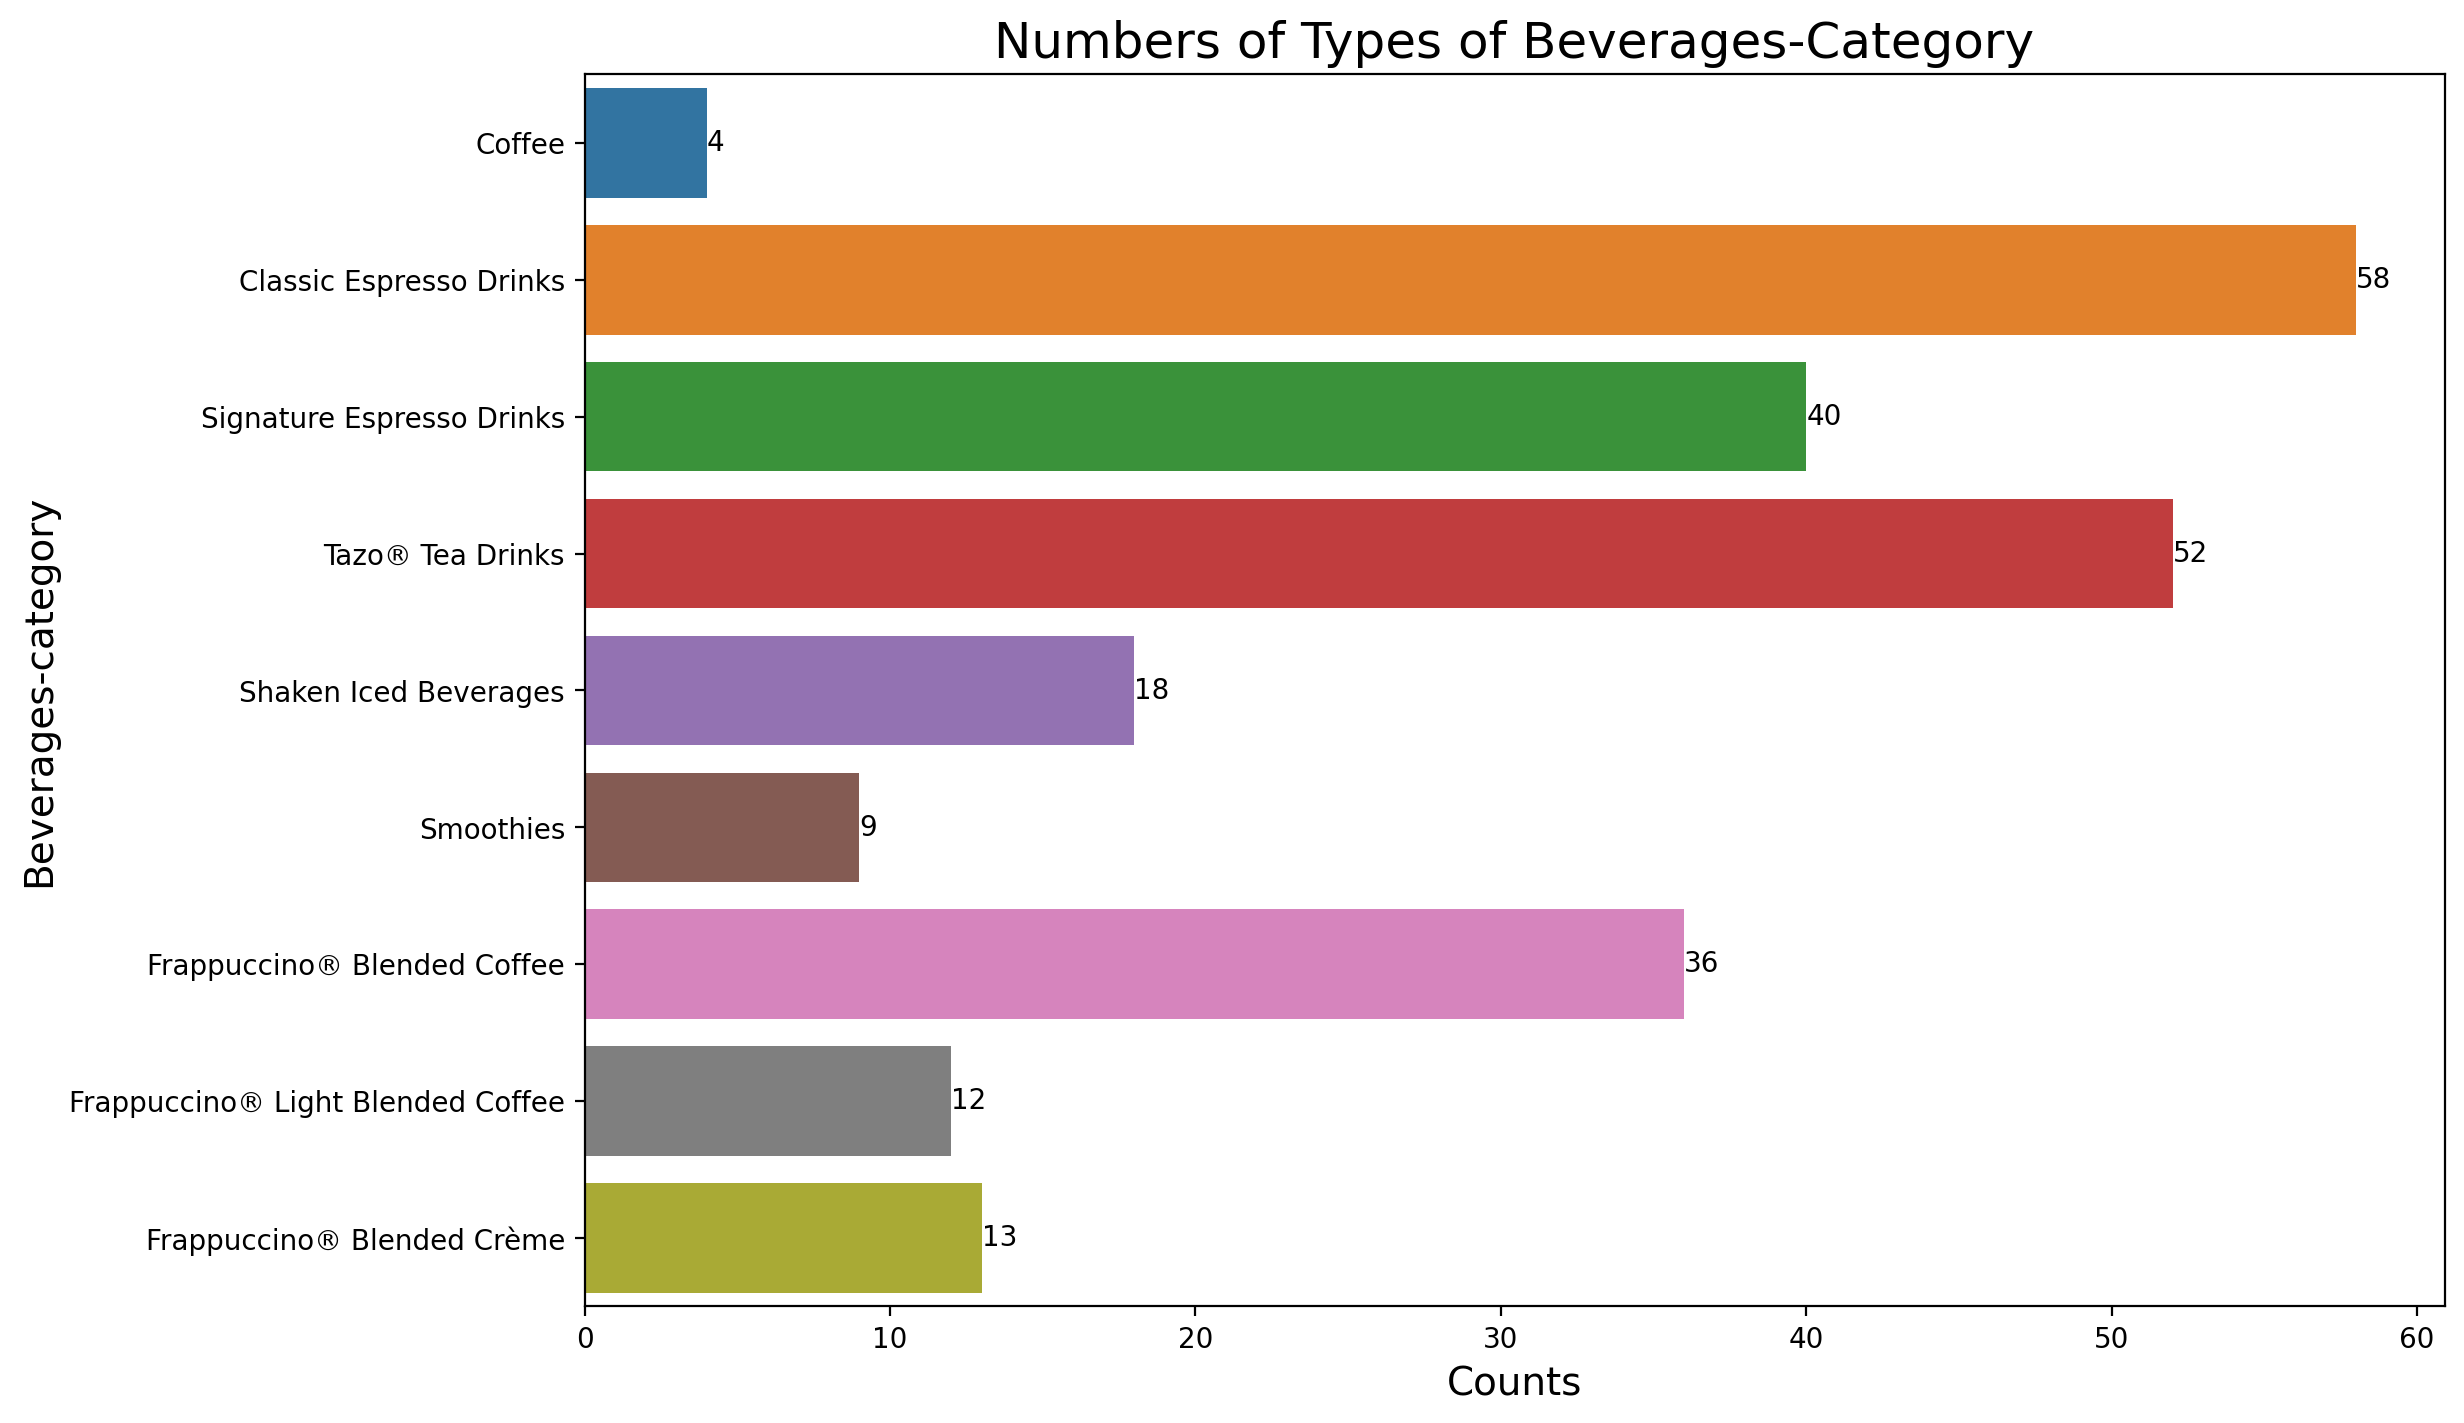

In [33]:
plt.figure(figsize = (12,8), dpi = 200)
ax = sns.countplot(y = 'Beverage_category', data = df2)
for bars in ax.containers:
    ax.bar_label(bars)

ax.set_xlabel('Counts', size = 14)    
ax.set_ylabel('Beverages-category', size = 14)
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.title("Numbers of Types of Beverages-Category", size = 18)
plt.show()

<b> In Beverage Category, Type of classic espresso drink is the highest number of type of drinks which is 58

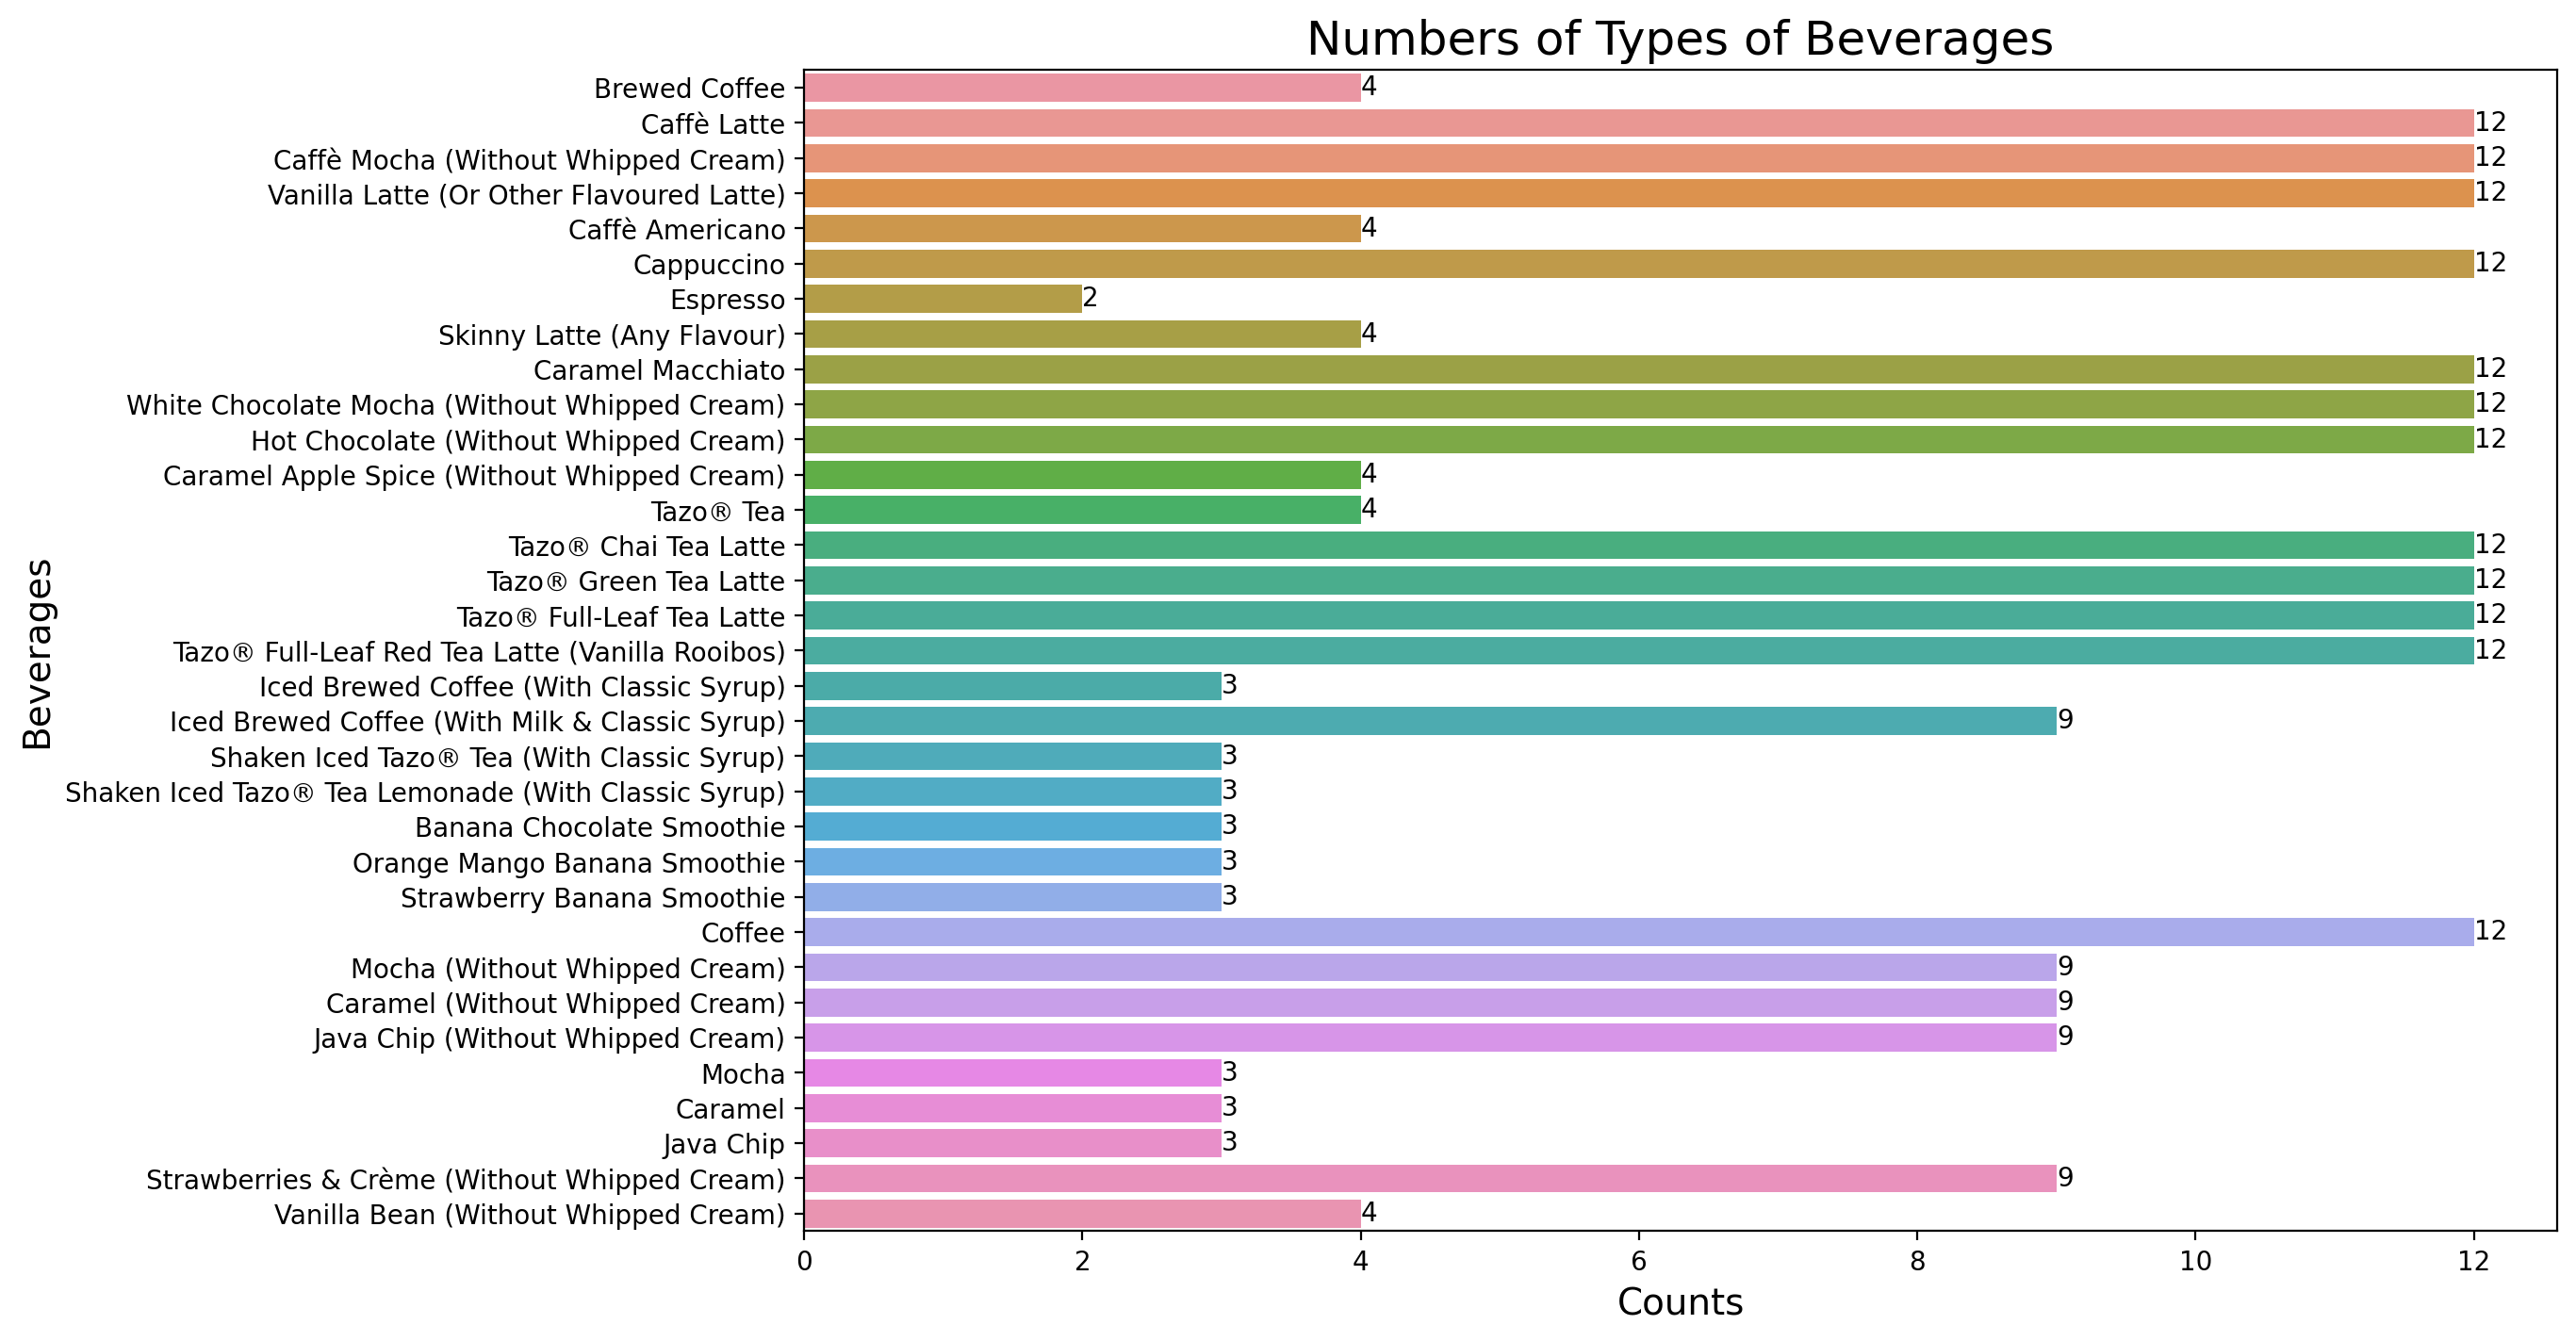

In [34]:
plt.figure(figsize = (12,8), dpi = 200)
ax = sns.countplot(y = 'Beverage', data = df2)
for bars in ax.containers:
    ax.bar_label(bars)

ax.set_xlabel('Counts', size = 14)    
ax.set_ylabel('Beverages', size = 14)
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.title("Numbers of Types of Beverages", size = 18)
plt.show()

<b> In Beverage, Types of espresso is the lowest number of type of drinks which is 2

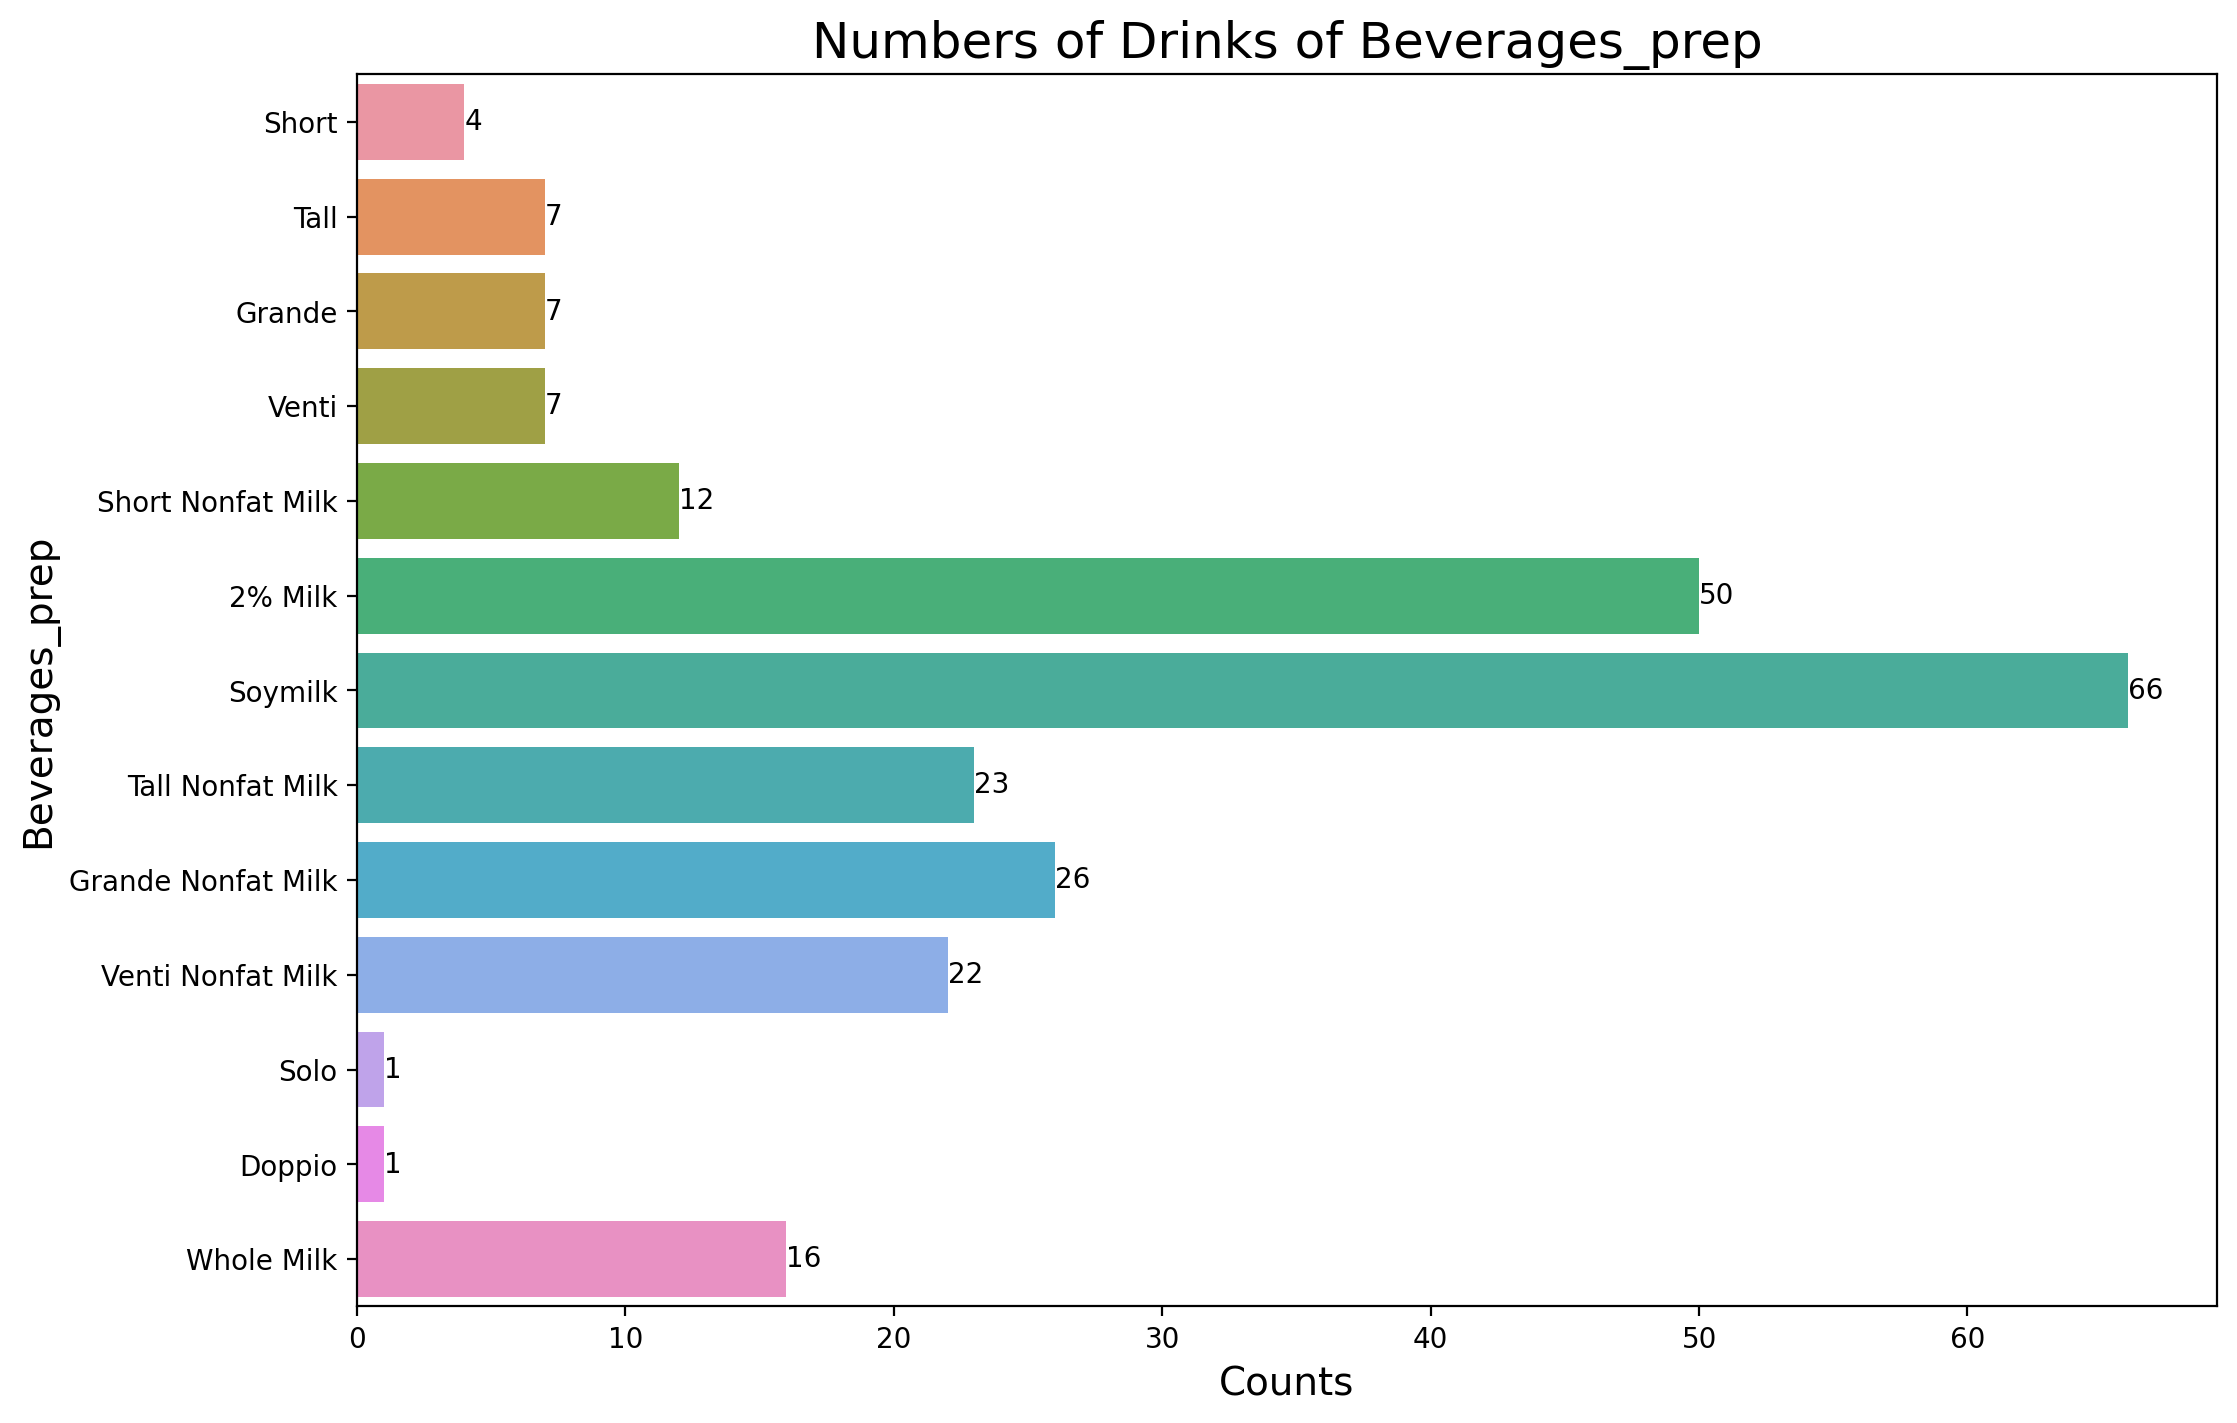

In [35]:
plt.figure(figsize = (12,8), dpi = 200)
ax = sns.countplot(y = 'Beverage_prep', data = df2)
for bars in ax.containers:
    ax.bar_label(bars)

ax.set_xlabel('Counts', size = 14)    
ax.set_ylabel('Beverages_prep', size = 14)
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
plt.title("Numbers of Drinks of Beverages_prep", size = 18)
plt.show()

<b> Highest number of Beverage prepartion by soymilk which is 66

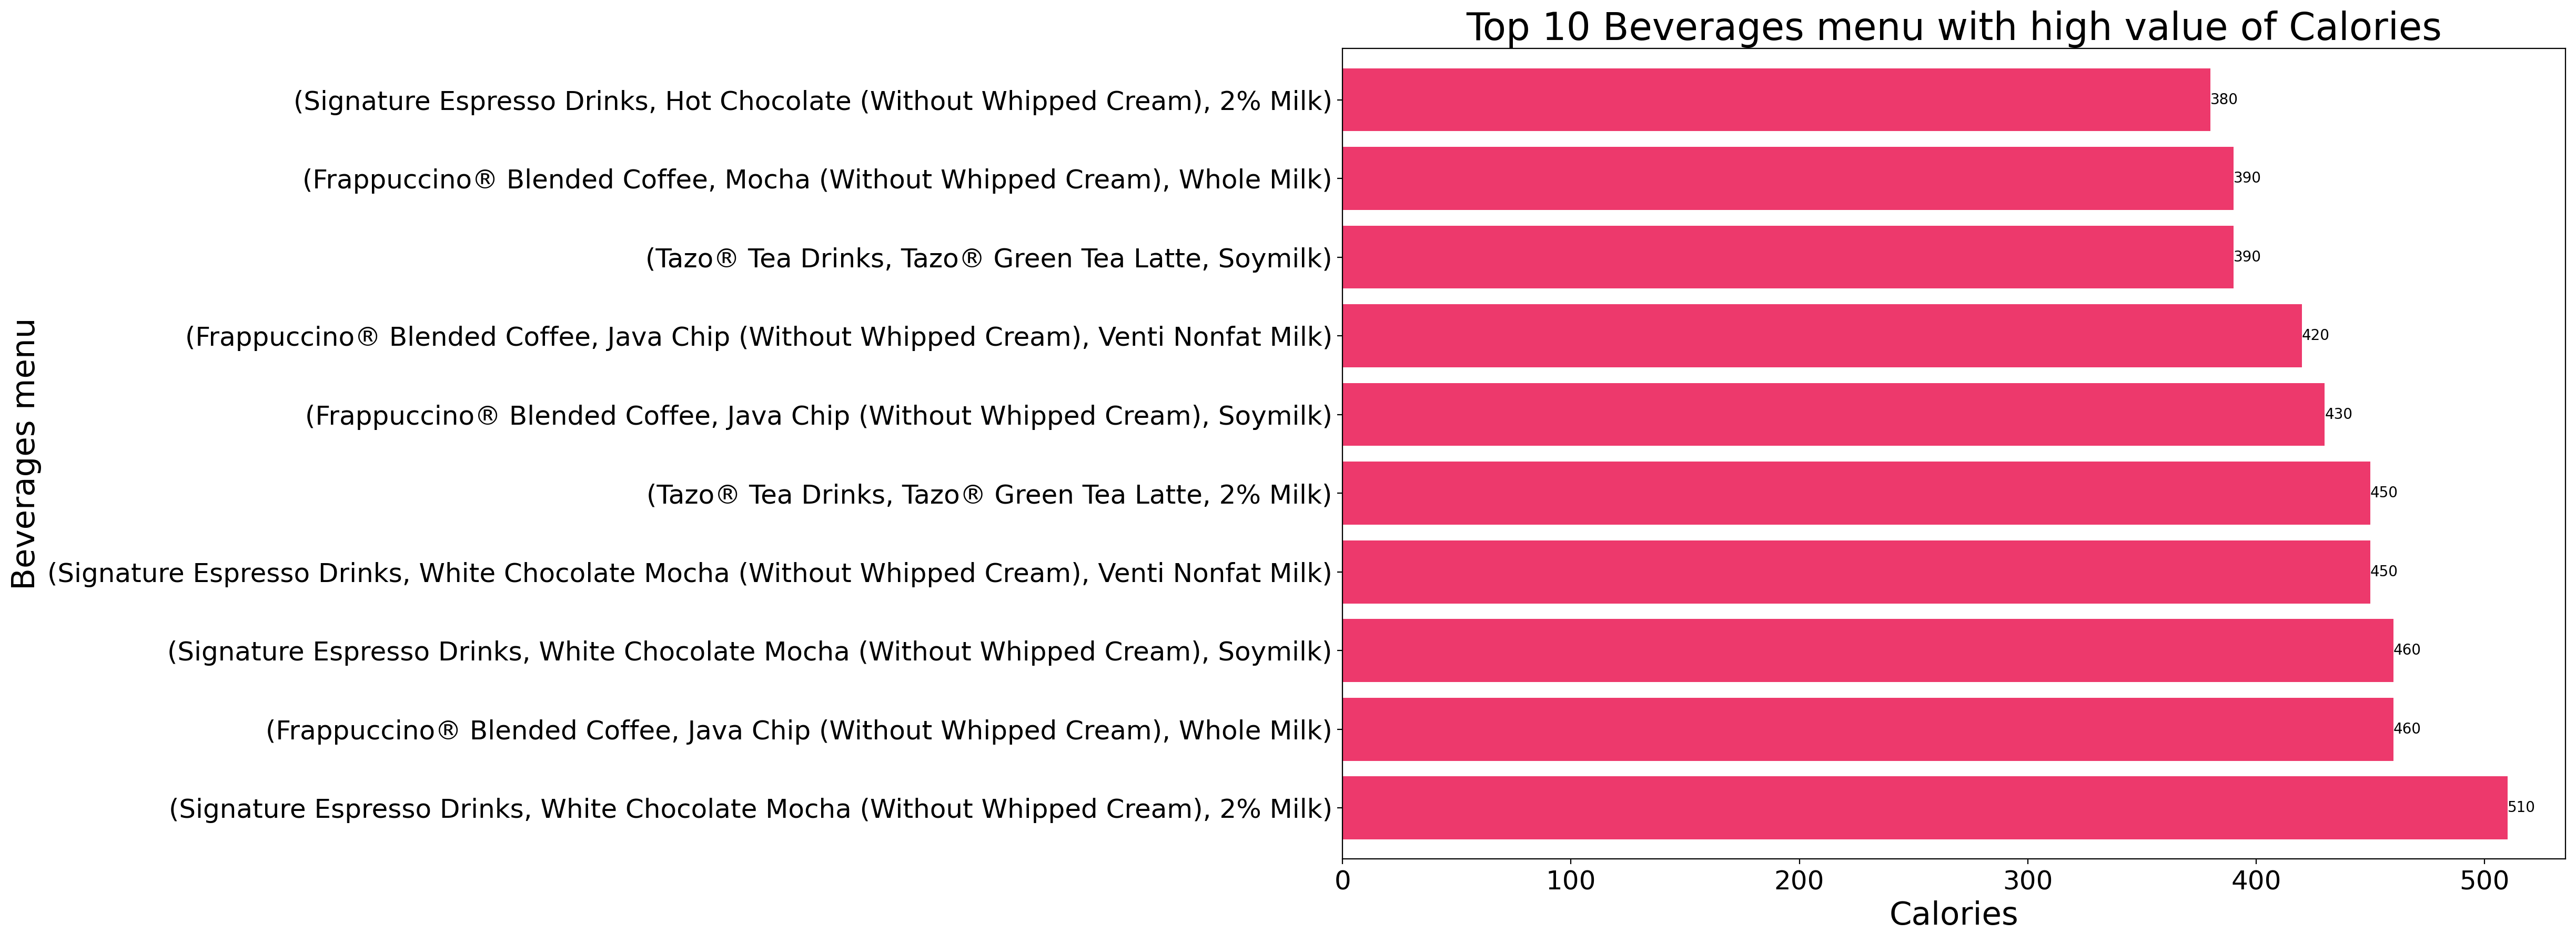

In [36]:
 #Top 10 Drinks with High value of Calories

x = df2.groupby(['Beverage_category','Beverage', 'Beverage_prep']).max()['Calories'].sort_values(ascending=False)[:10]
plt.figure(figsize = (15,10), dpi = 200)
ax = x.plot(kind = 'barh', width = 0.8,color = '#ed396c' )
for bars in ax.containers :
    ax.bar_label(bars)
    
ax.set_xlabel('Calories', size = 22)    
ax.set_ylabel('Beverages menu', size = 22)    
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.title("Top 10 Beverages menu with high value of Calories", size = 26)
plt.show()

<b> 'Signature Espresso Drinks(White Chocolate Mocha without whipped cream), 2% Milk' is the Highest number of Calories Drink which is 510

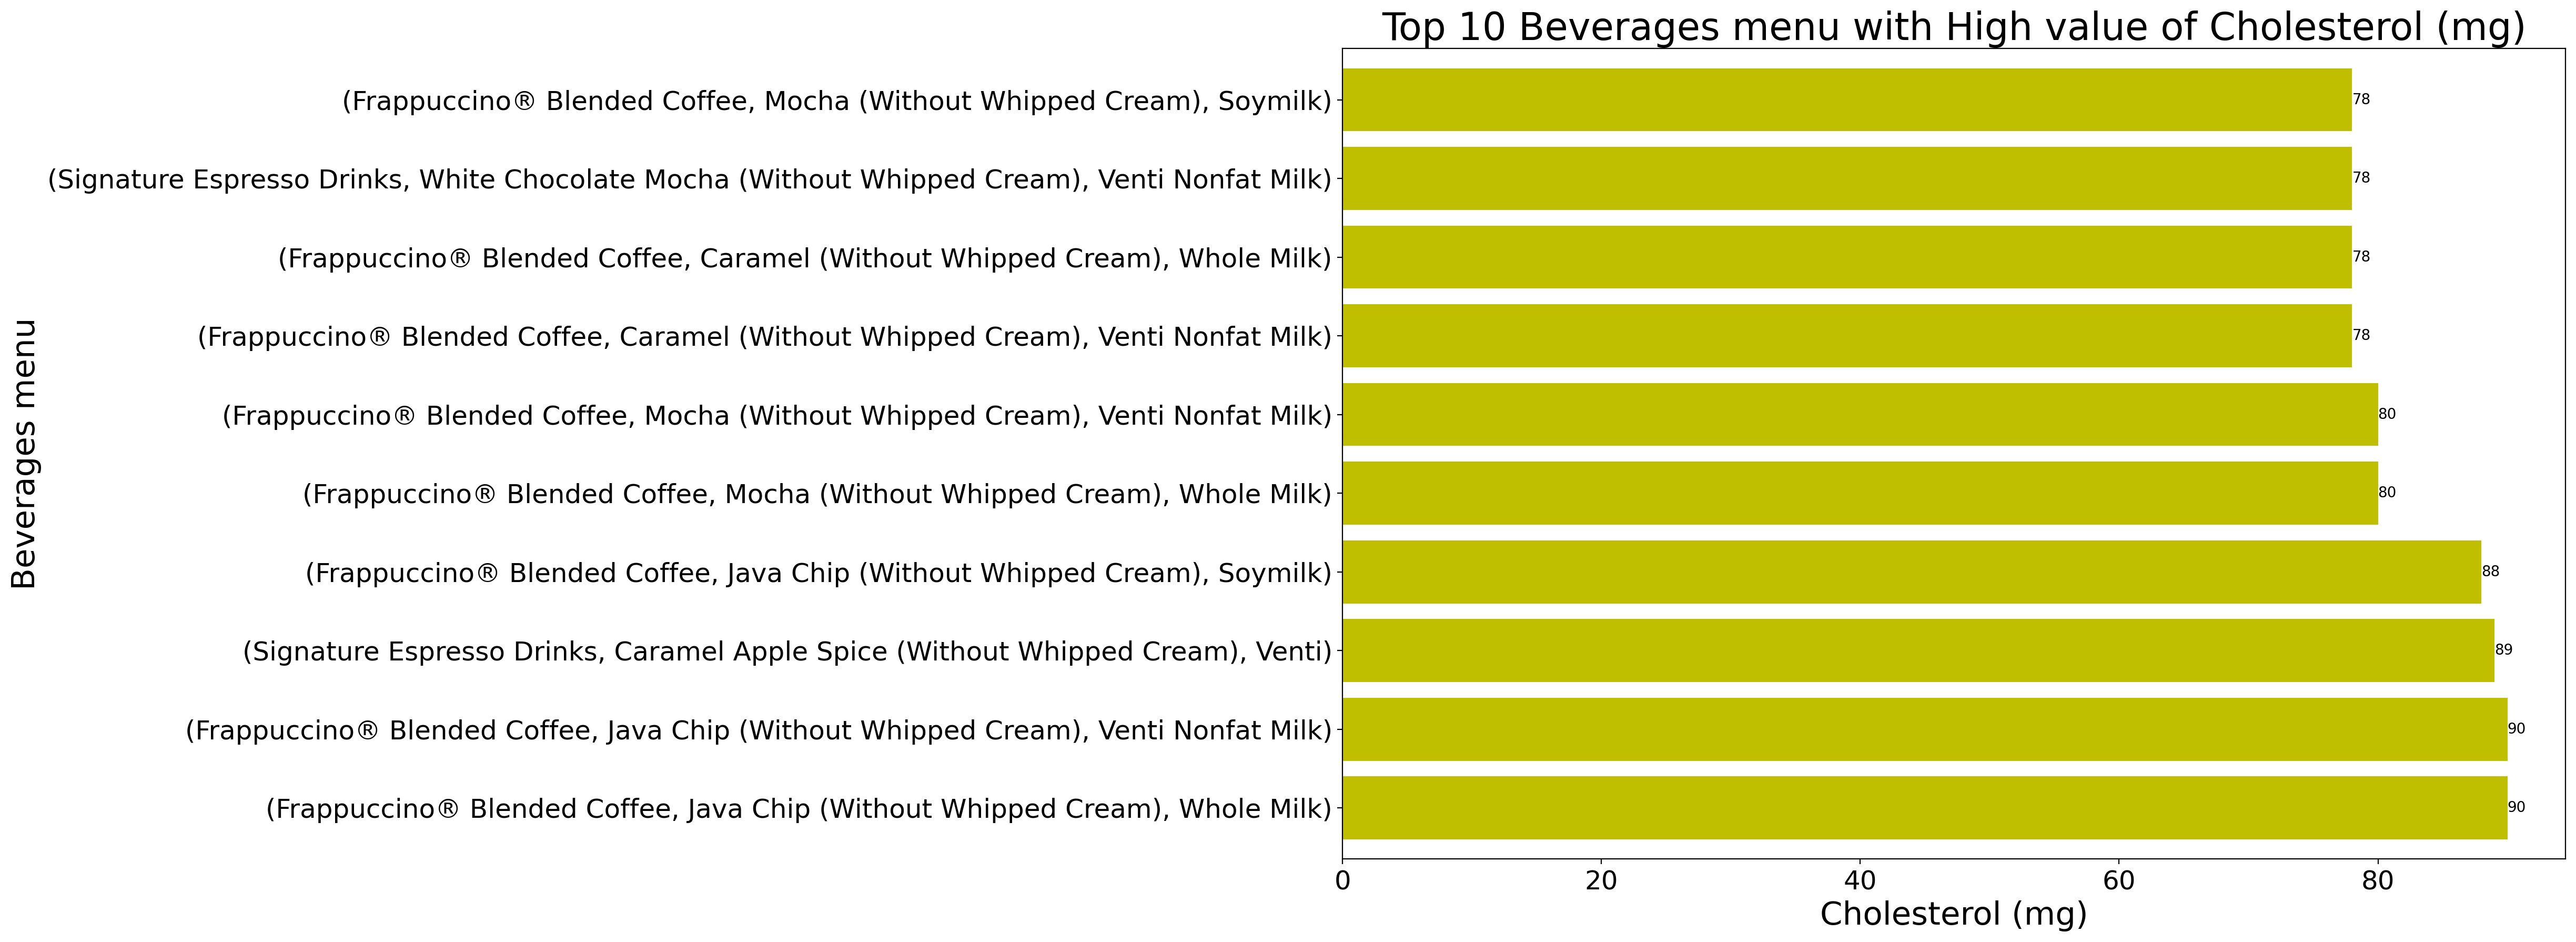

In [37]:
x = df2.groupby(['Beverage_category','Beverage', 'Beverage_prep']).max()['Cholesterol (mg)'].sort_values(ascending=False)[:10] 
plt.figure(figsize = (15,10), dpi = 200)
ax = x.plot(kind = 'barh', width = 0.8,color = 'y' )
for bars in ax.containers :
    ax.bar_label(bars)
    
ax.set_xlabel('Cholesterol (mg)', size = 22)    
ax.set_ylabel('Beverages menu', size = 22)  
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.title("Top 10 Beverages menu with High value of Cholesterol (mg)", size = 26)
plt.show()

<b> Highest number of Cholestrol in 'Frappuccino Blended Coffee, java chip(without whipped cream),Whole milk', is 90mg

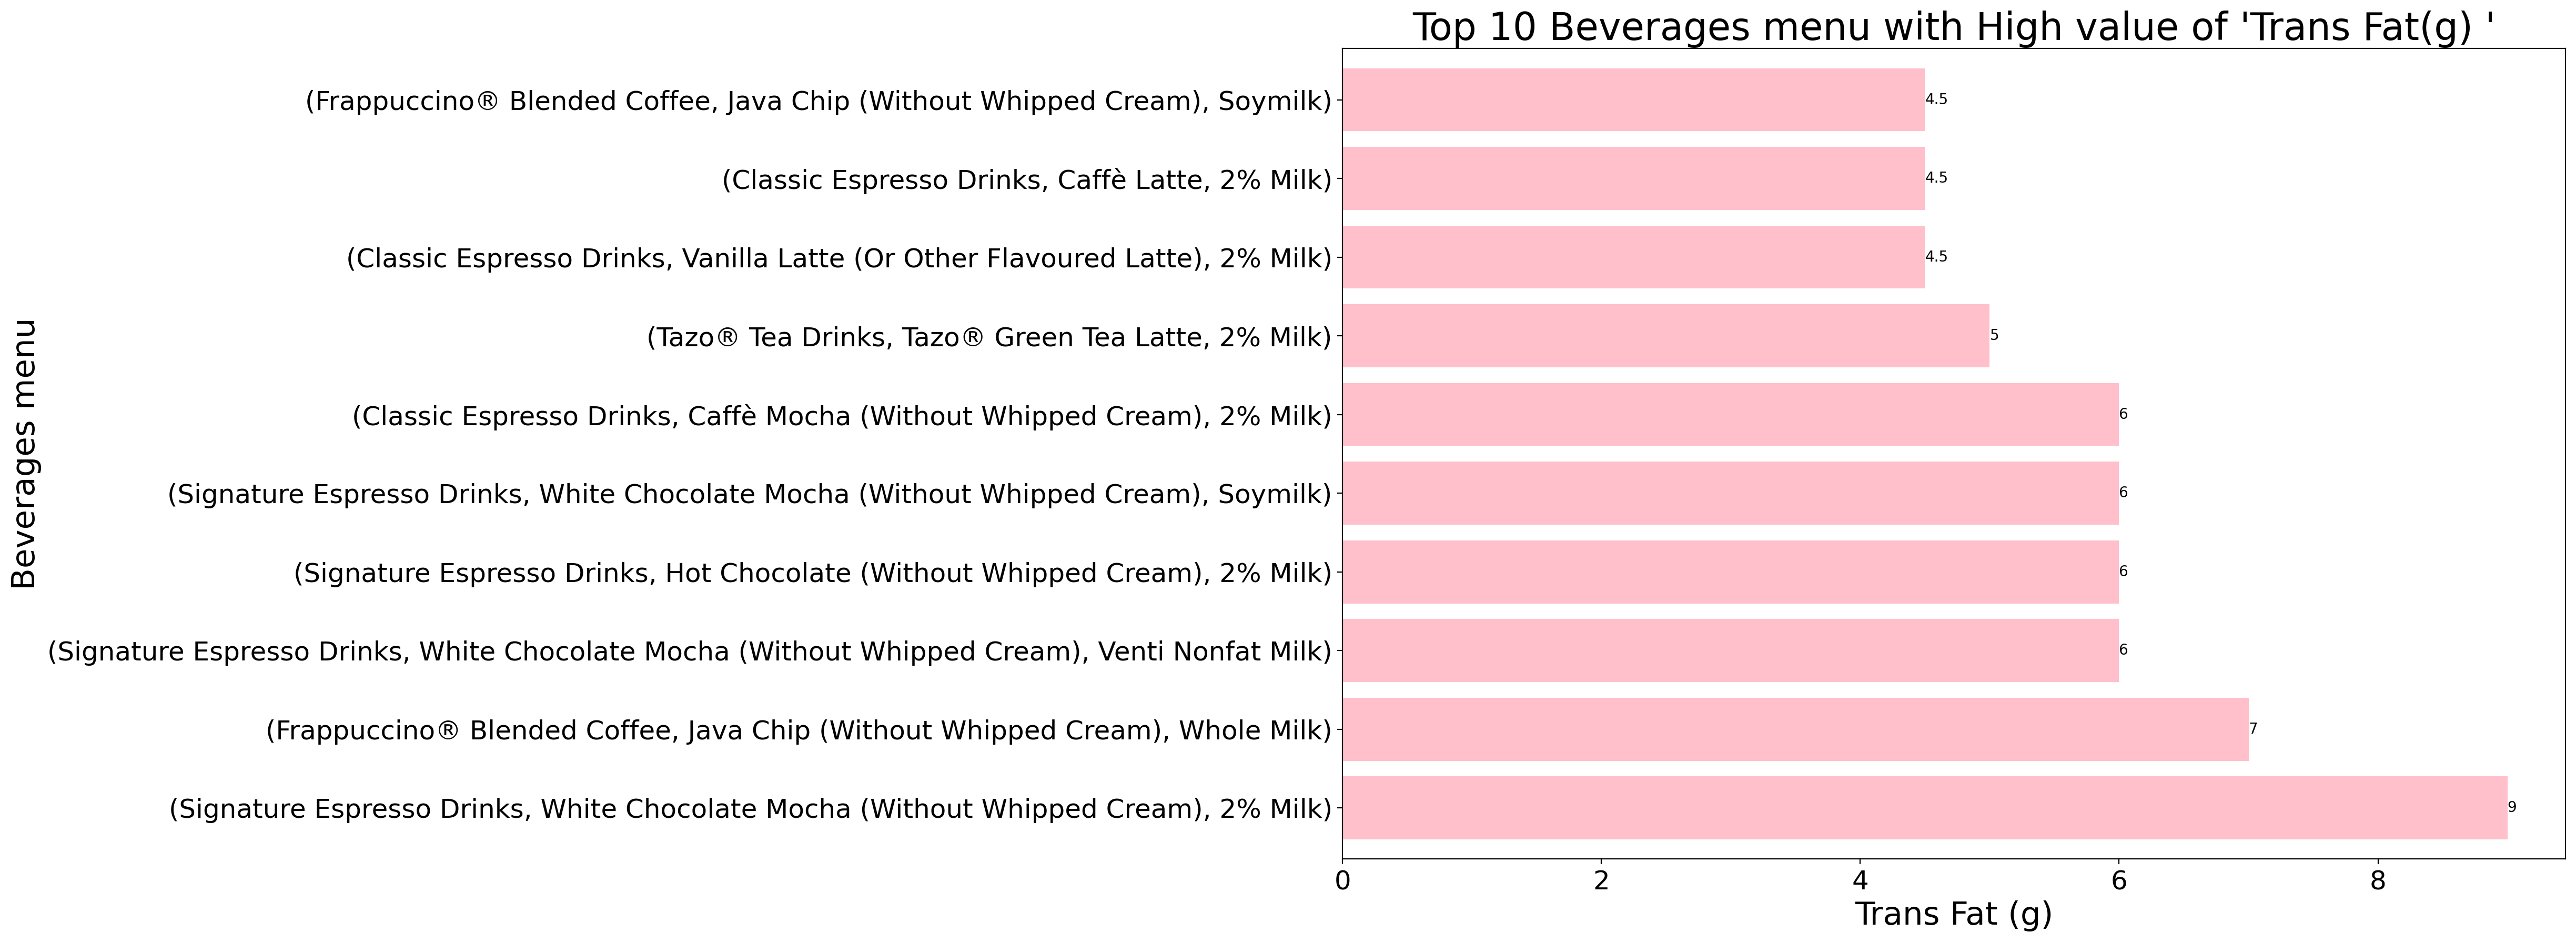

In [38]:
x = df2.groupby(['Beverage_category','Beverage', 'Beverage_prep']).max()['Trans Fat (g) '].sort_values(ascending=False)[:10] 
plt.figure(figsize = (15,10), dpi = 200)
ax = x.plot(kind = 'barh', width = 0.8,color = 'pink' )
for bars in ax.containers :
    ax.bar_label(bars)
    
ax.set_xlabel('Trans Fat (g)', size = 22)    
ax.set_ylabel('Beverages menu', size = 22)  
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.title("Top 10 Beverages menu with High value of 'Trans Fat(g) '", size = 26)
plt.show()

<b> (Signature Espresso Drinks(White Chocolate Mocha without whipped cream), 2% Milk) is the Highest number of TransFat(g) Beverages which is 9

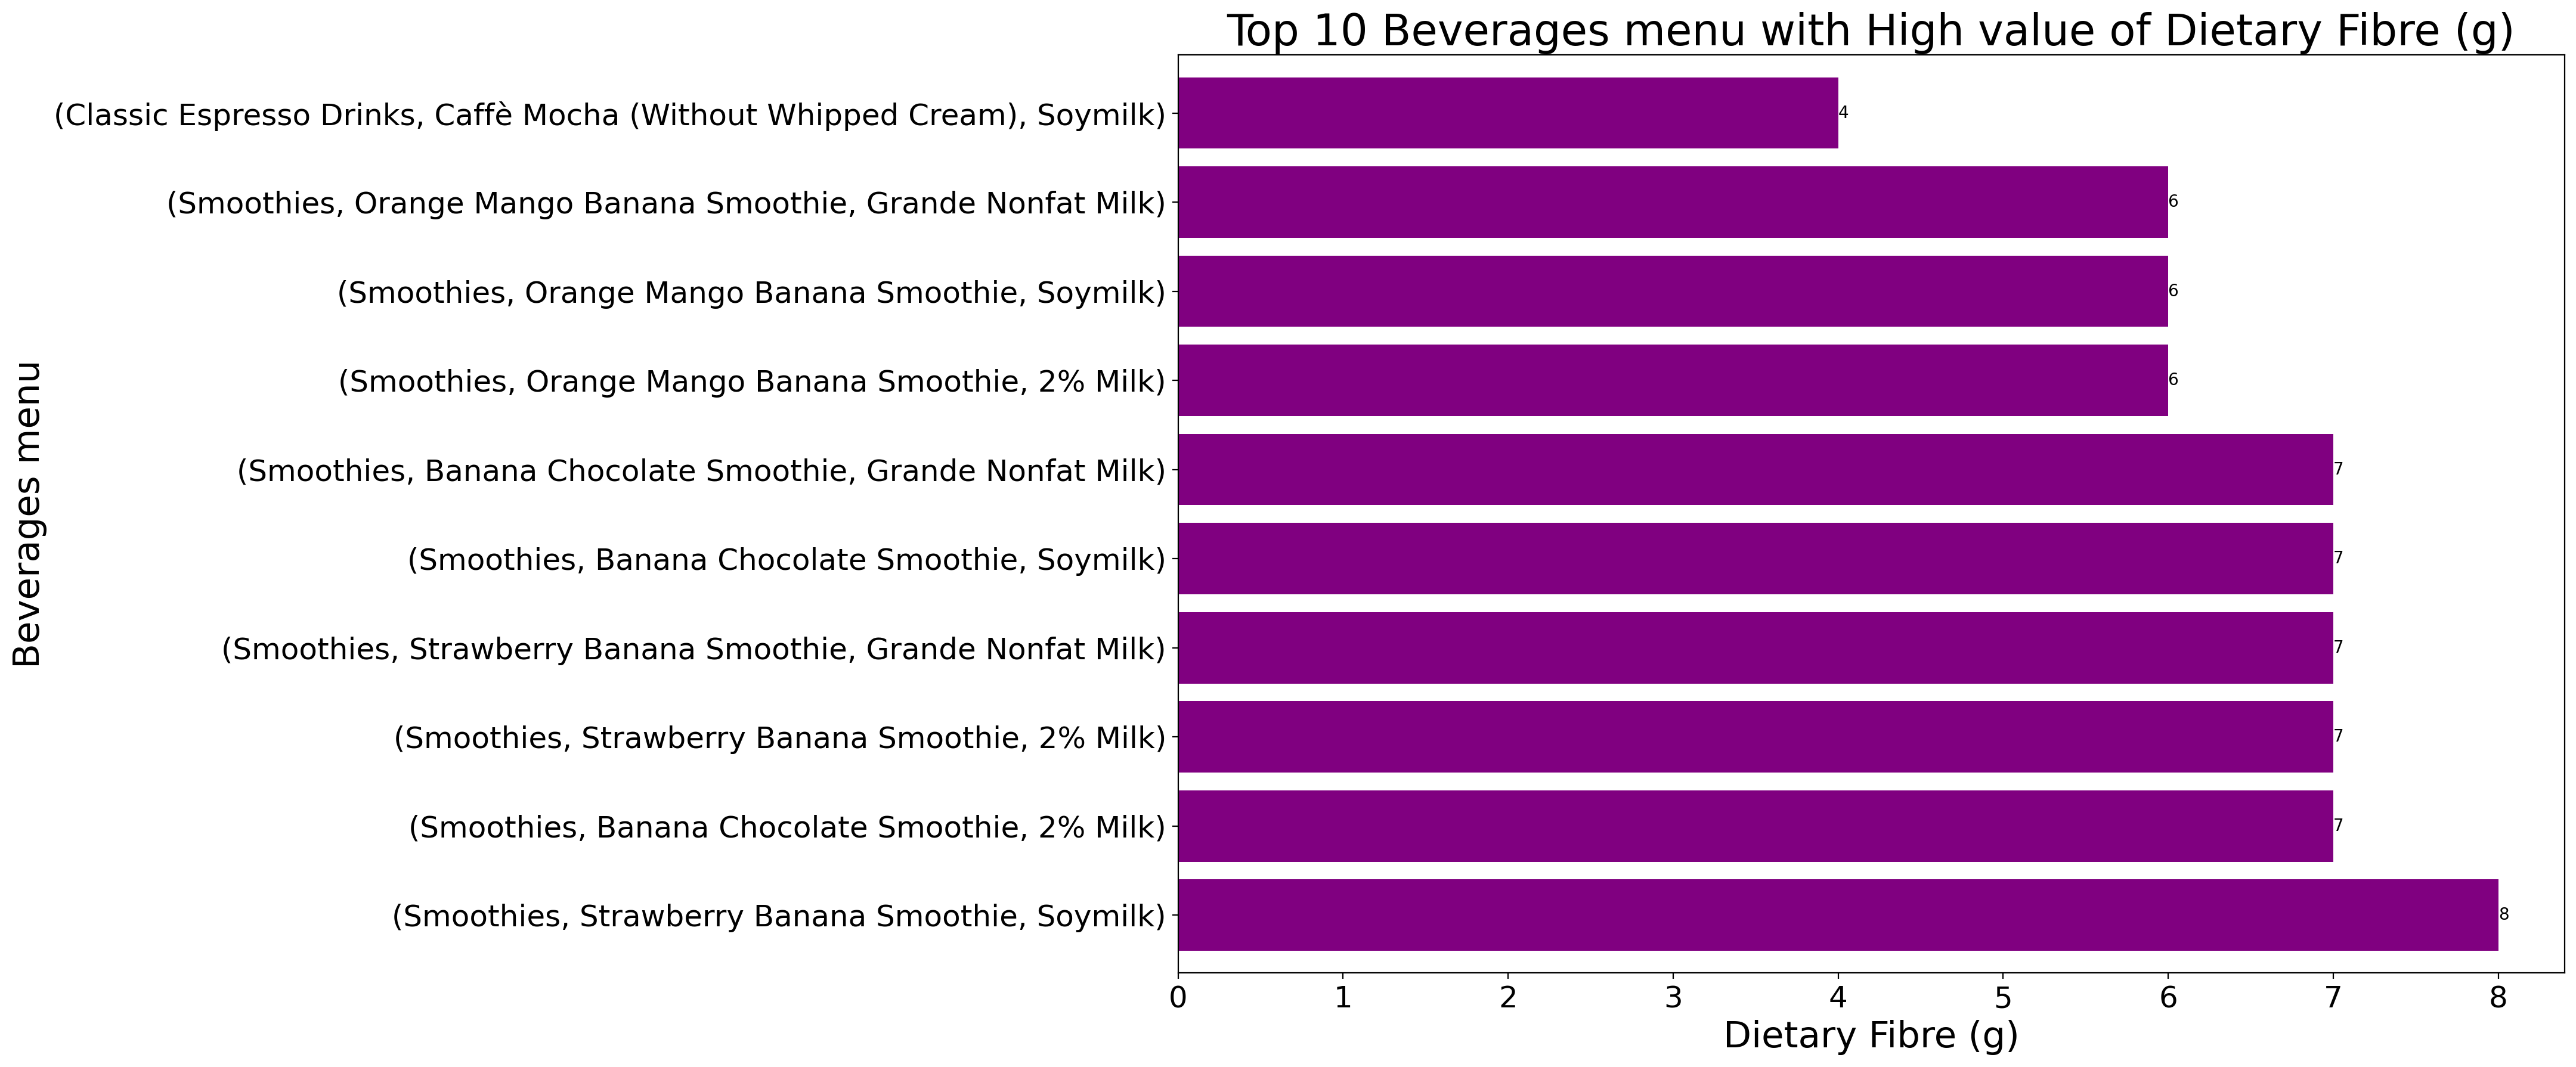

In [39]:
x = df2.groupby(['Beverage_category','Beverage', 'Beverage_prep']).max()[' Dietary Fibre (g)'].sort_values(ascending=False)[:10] 
plt.figure(figsize = (15,10), dpi = 200)
ax = x.plot(kind = 'barh', width = 0.8,color = 'purple' )
for bars in ax.containers :
    ax.bar_label(bars)
    
ax.set_xlabel('Dietary Fibre (g)', size = 22)    
ax.set_ylabel('Beverages menu', size = 22)  
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.title("Top 10 Beverages menu with High value of Dietary Fibre (g)", size = 26)
plt.show()

<b> Highest number of Dietary Fibre in ('Smoothies, Strawberry Banana Smoothie, soymilk'), is 8g

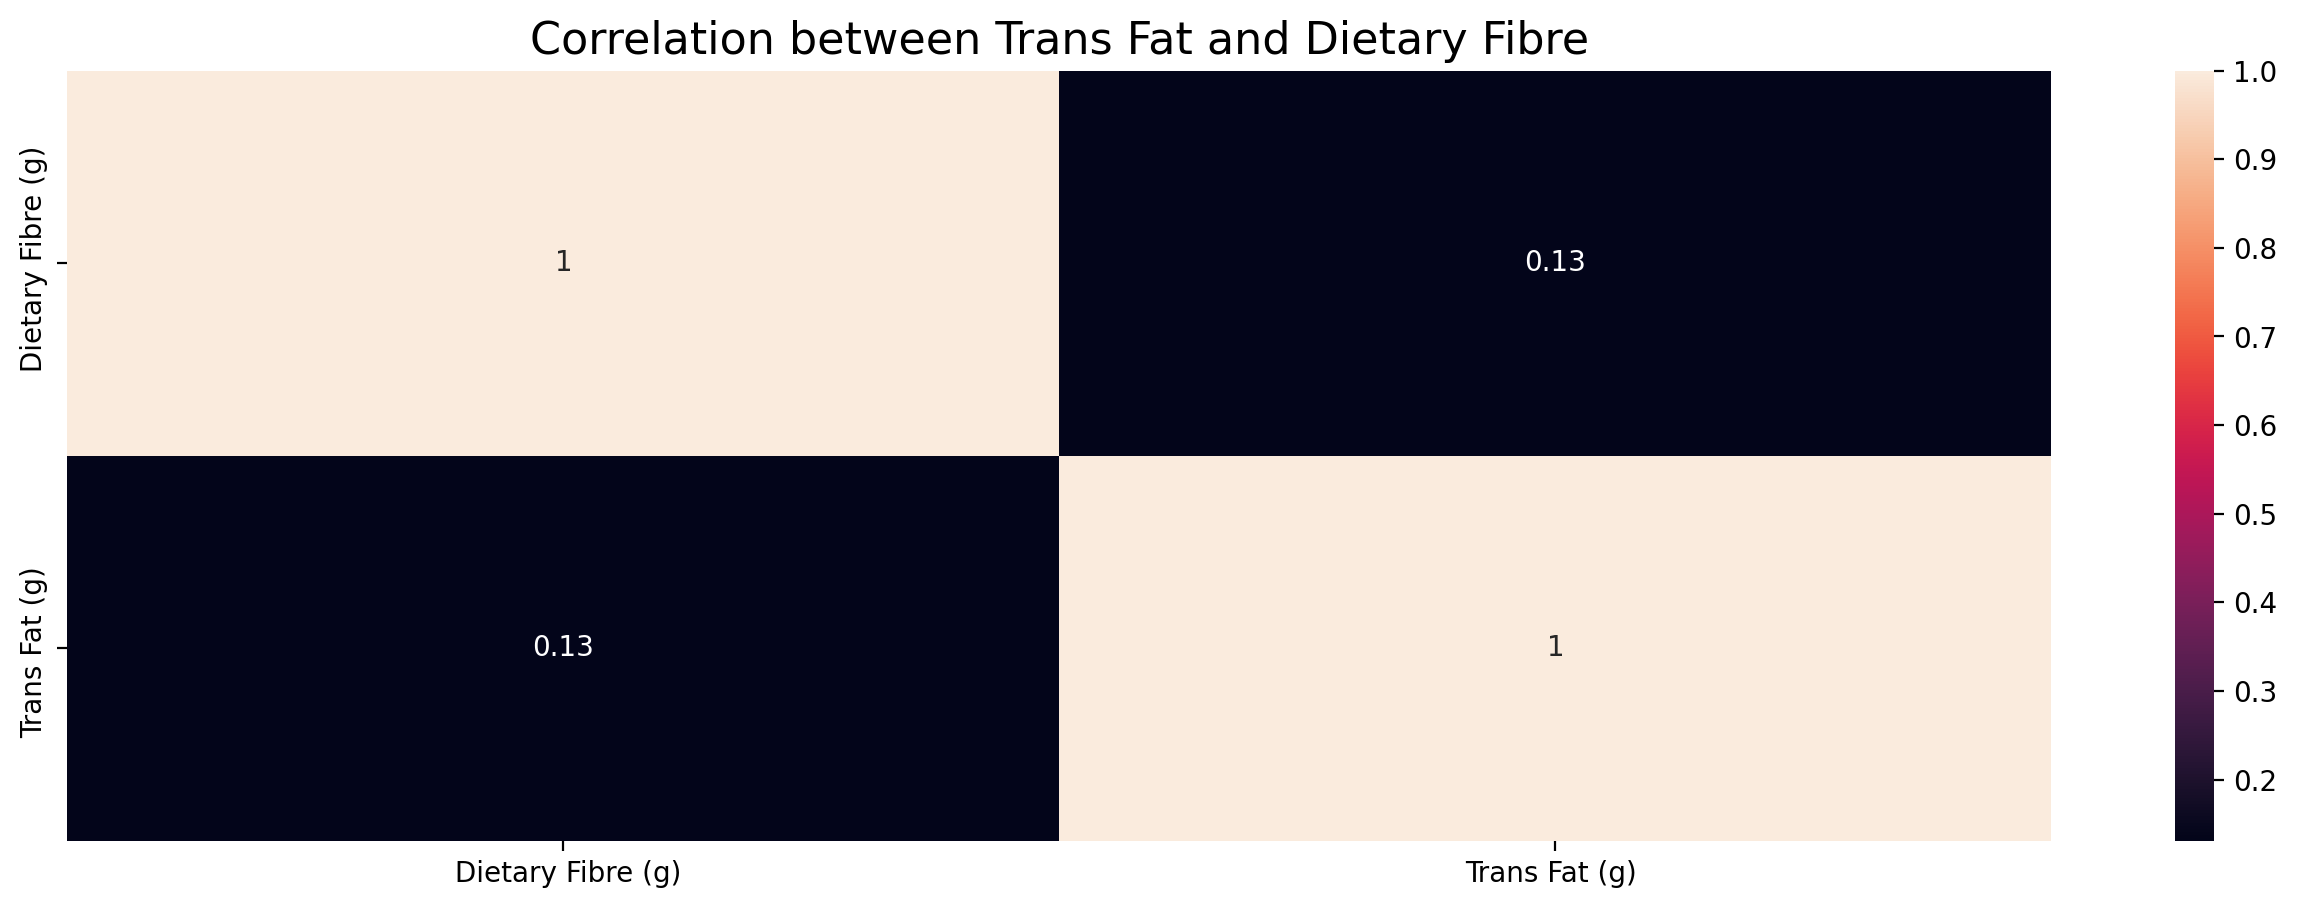

In [40]:
plt.figure(figsize = (16,5), dpi = 200)
sns.heatmap(df2[[' Dietary Fibre (g)','Trans Fat (g) ']].corr(), annot = True)
plt.title('Correlation between Trans Fat and Dietary Fibre', size = 16)
plt.show()

<b> we can see that 'Correlation between Trans Fat and Dietary Fibre', whenever Dietary Fibre(g) is high Trans Fat is low and Vice Versa

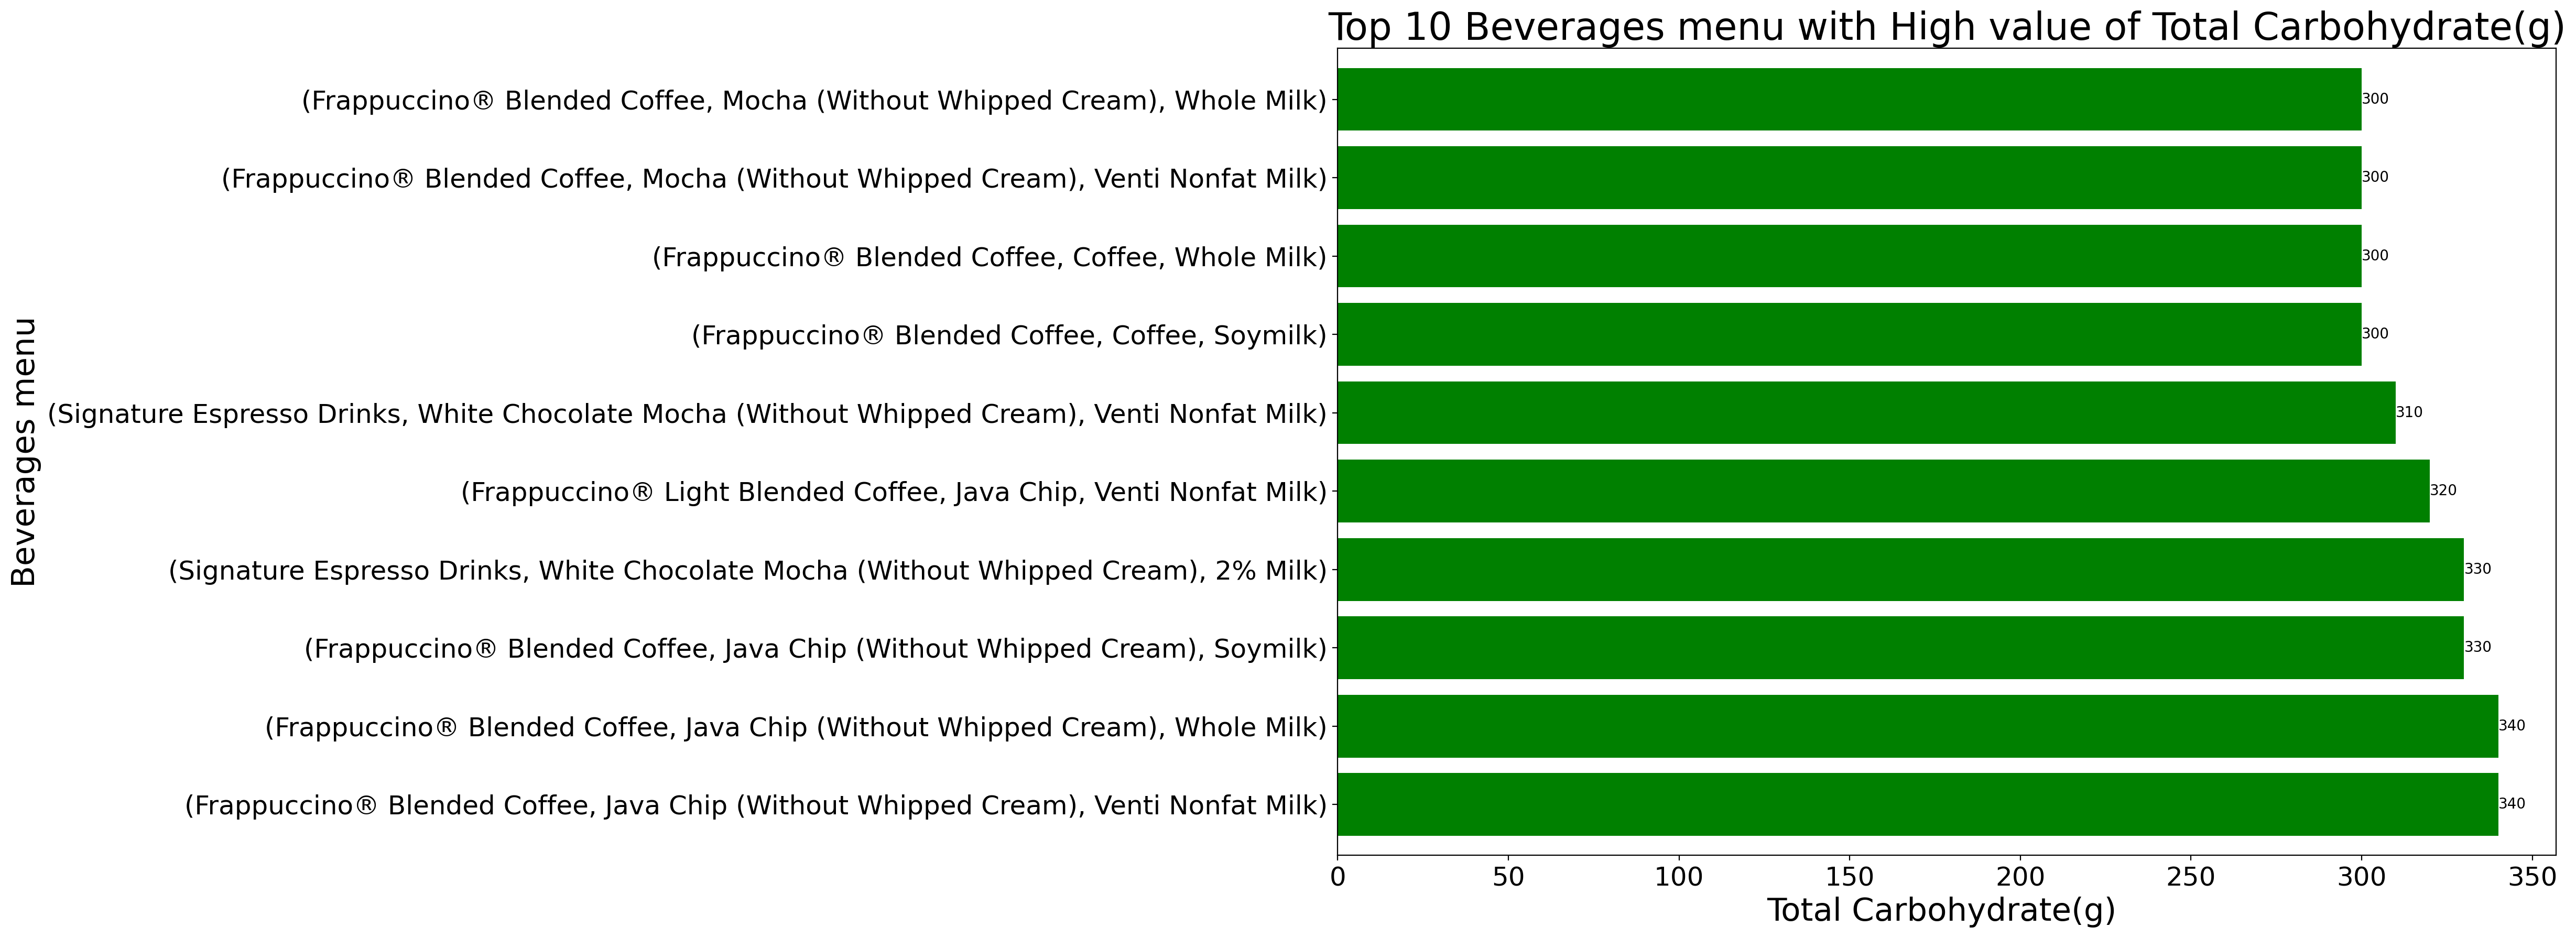

In [41]:
x = df2.groupby(['Beverage_category','Beverage', 'Beverage_prep']).max()[' Total Carbohydrates (g) '].sort_values(ascending=False)[:10] 
plt.figure(figsize = (15,10), dpi = 200)
ax = x.plot(kind = 'barh', width = 0.8,color = 'g' )
for bars in ax.containers :
    ax.bar_label(bars)
    
ax.set_xlabel('Total Carbohydrate(g) ', size = 22)    
ax.set_ylabel('Beverages menu', size = 22)    
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.title("Top 10 Beverages menu with High value of Total Carbohydrate(g)", size = 26)
plt.show()

<b> Highest number of Total Carbohydrates in ('Frappuccino Blended Coffee, java chip(without whipped cream),Venti Nonfat milk'), is 340g

In [42]:
df3.shape

(113, 6)

In [43]:
df3.head()

,Unnamed: 0,Calories,Fat (g),Carb. (g),Fiber (g),Protein (g)
0,Chonga Bagel,300,5.0,50,3,12
1,8-Grain Roll,380,6.0,70,7,10
2,Almond Croissant,410,22.0,45,3,10
3,Apple Fritter,460,23.0,56,2,7
4,Banana Nut Bread,420,22.0,52,2,6


In [44]:
df3.rename(columns ={'Unnamed: 0' : 'Snacks'},inplace = True)

In [45]:
df3.head(2)

,Snacks,Calories,Fat (g),Carb. (g),Fiber (g),Protein (g)
0,Chonga Bagel,300,5.0,50,3,12
1,8-Grain Roll,380,6.0,70,7,10


In [46]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Snacks        113 non-null    object 
 1    Calories     113 non-null    int64  
 2    Fat (g)      113 non-null    float64
 3    Carb. (g)    113 non-null    int64  
 4    Fiber (g)    113 non-null    int64  
 5    Protein (g)  113 non-null    int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 5.4+ KB


In [47]:
df3.duplicated().sum()

0

In [48]:
df3.isnull().sum()

Snacks          0
 Calories       0
 Fat (g)        0
 Carb. (g)      0
 Fiber (g)      0
 Protein (g)    0
dtype: int64

In [49]:
df3.nunique()

Snacks          113
 Calories        44
 Fat (g)         35
 Carb. (g)       49
 Fiber (g)       13
 Protein (g)     29
dtype: int64

In [50]:
df3.describe(include = 'object')

,Snacks
count,113
unique,113
top,Chonga Bagel
freq,1


In [51]:
df3.describe()

,Calories,Fat (g),Carb. (g),Fiber (g),Protein (g)
count,113.000000,113.000000,113.000000,113.000000,113.000000
mean,356.637168,16.353982,41.486726,2.849558,11.469027
std,127.710685,8.297397,15.796764,2.888466,8.463230
min,90.000000,0.000000,5.000000,0.000000,1.000000
25%,280.000000,9.000000,31.000000,1.000000,5.000000
50%,360.000000,17.000000,42.000000,2.000000,8.000000
75%,450.000000,23.000000,53.000000,3.000000,19.000000
max,650.000000,37.000000,80.000000,21.000000,34.000000


In [52]:
df3.columns

Index(['Snacks', ' Calories', ' Fat (g)', ' Carb. (g)', ' Fiber (g)',
       ' Protein (g)'],
      dtype='object')

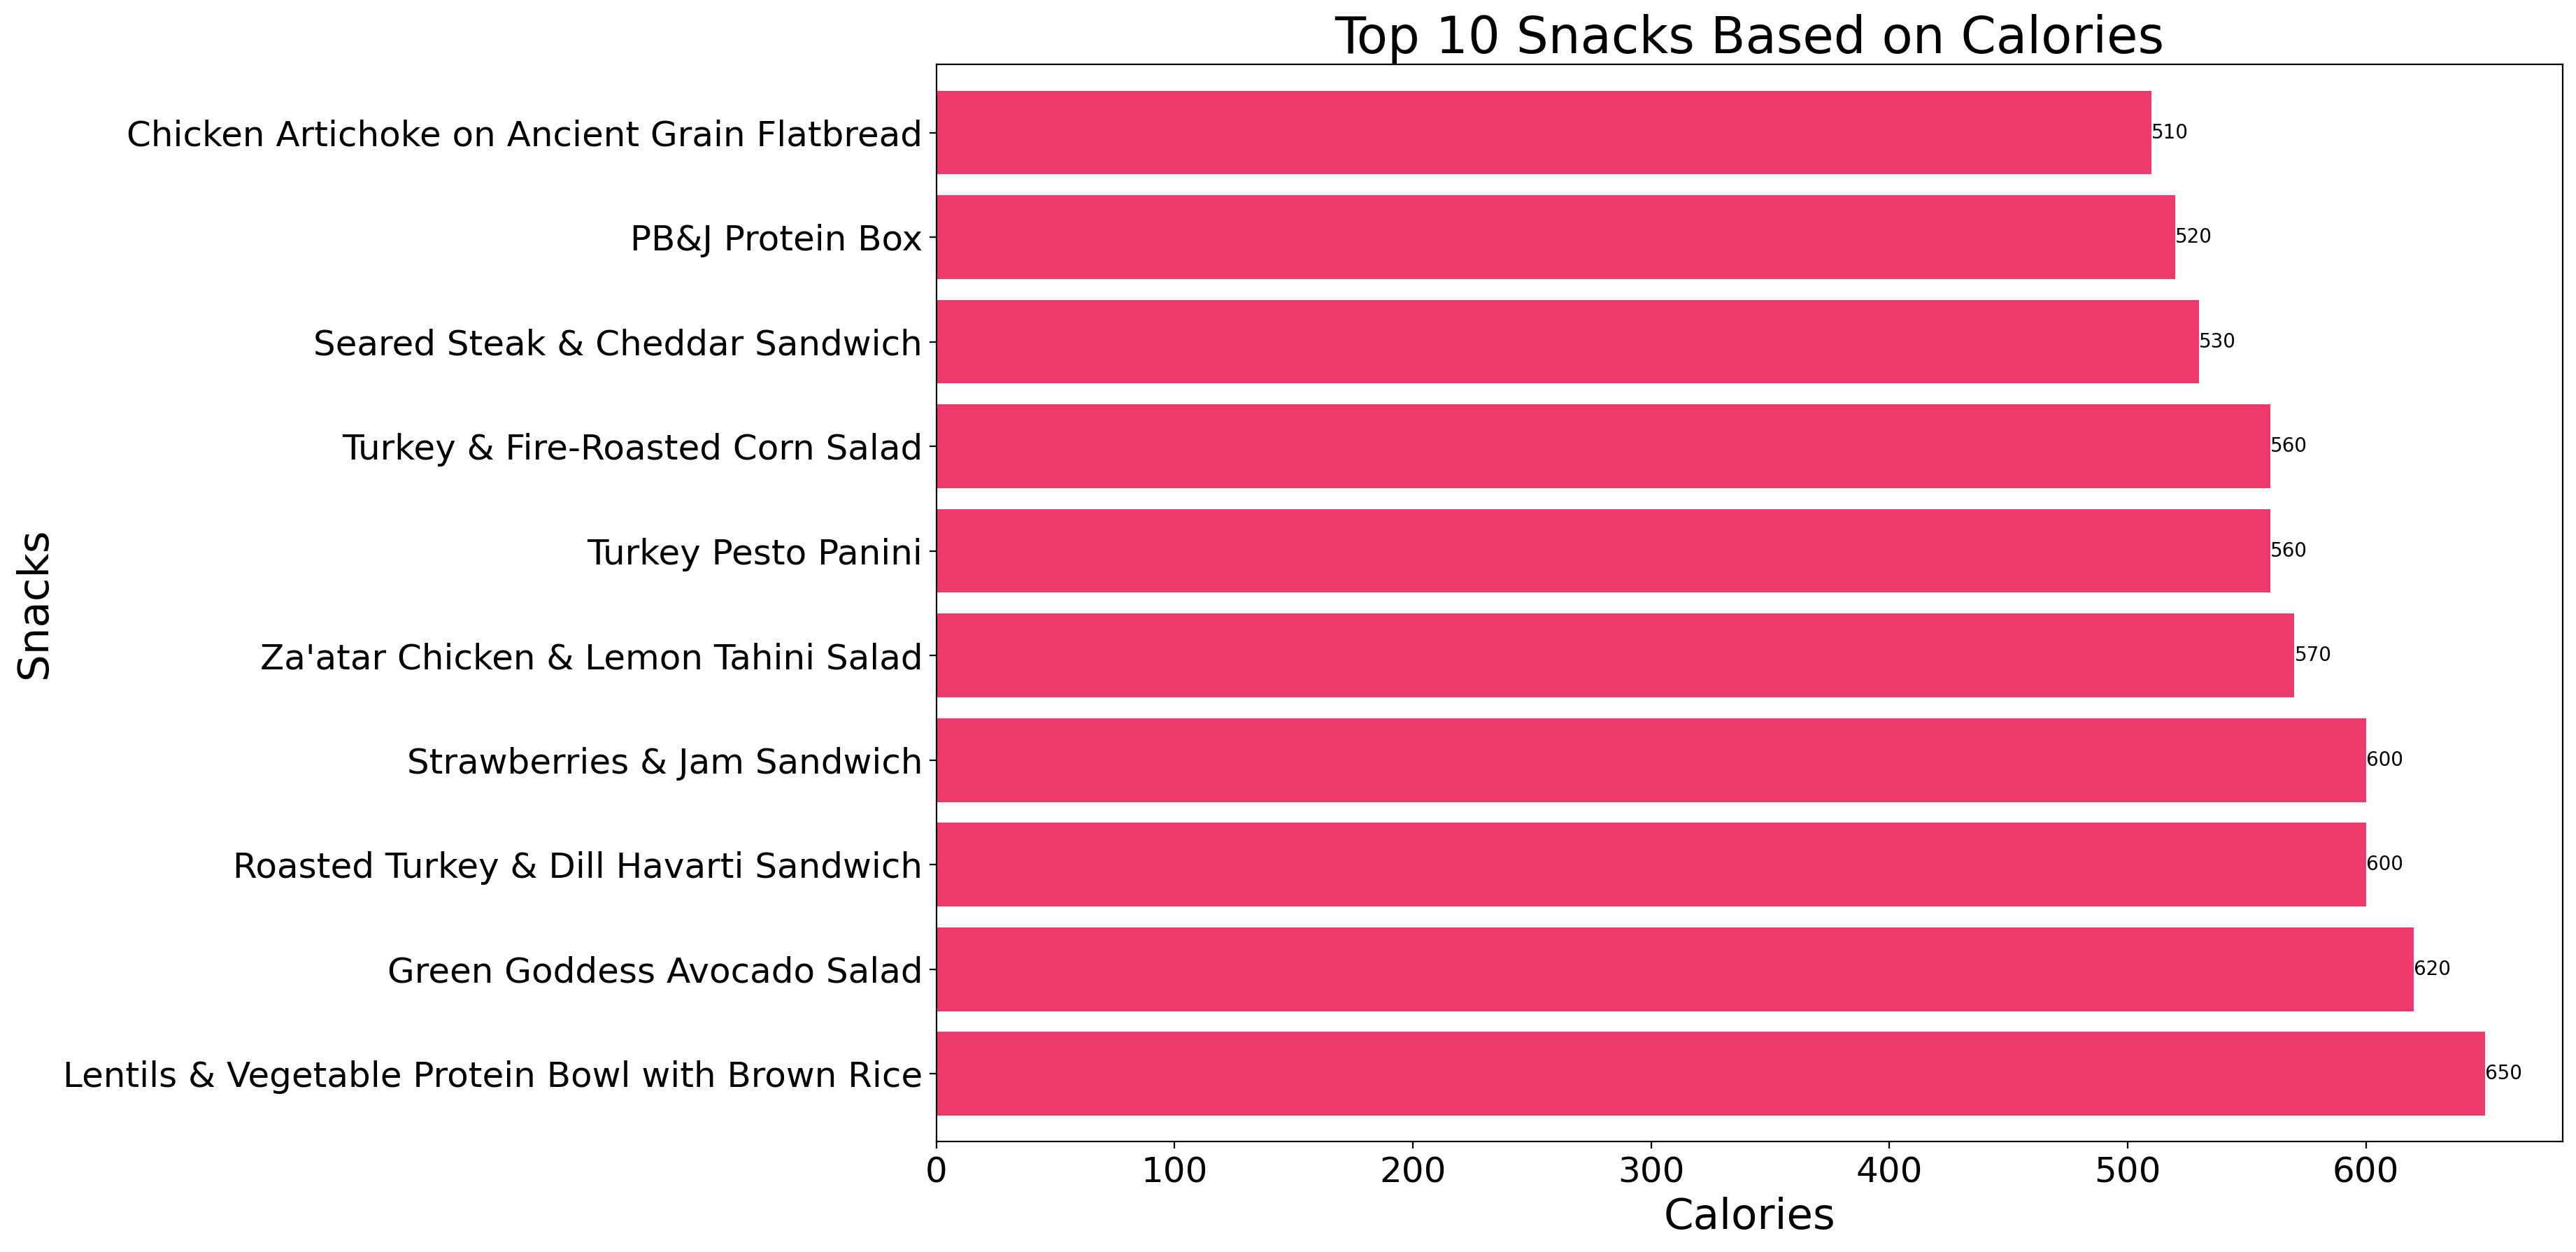

In [53]:
x = df3.groupby(['Snacks']).max()[' Calories'].sort_values(ascending=False)[:10] 
plt.figure(figsize = (15,10), dpi = 200)
ax = x.plot(kind = 'barh', width = 0.8,color = '#ed396c' )
for bars in ax.containers :
    ax.bar_label(bars)
    
ax.set_xlabel('Calories', size = 22)    
ax.set_ylabel('Snacks', size = 22)    
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.title("Top 10 Snacks Based on Calories", size = 26)
plt.show()

<b> Highest Calories of the Snacks is 'Lentils $ Vegetable Protein Bowl Rice' , which is 650

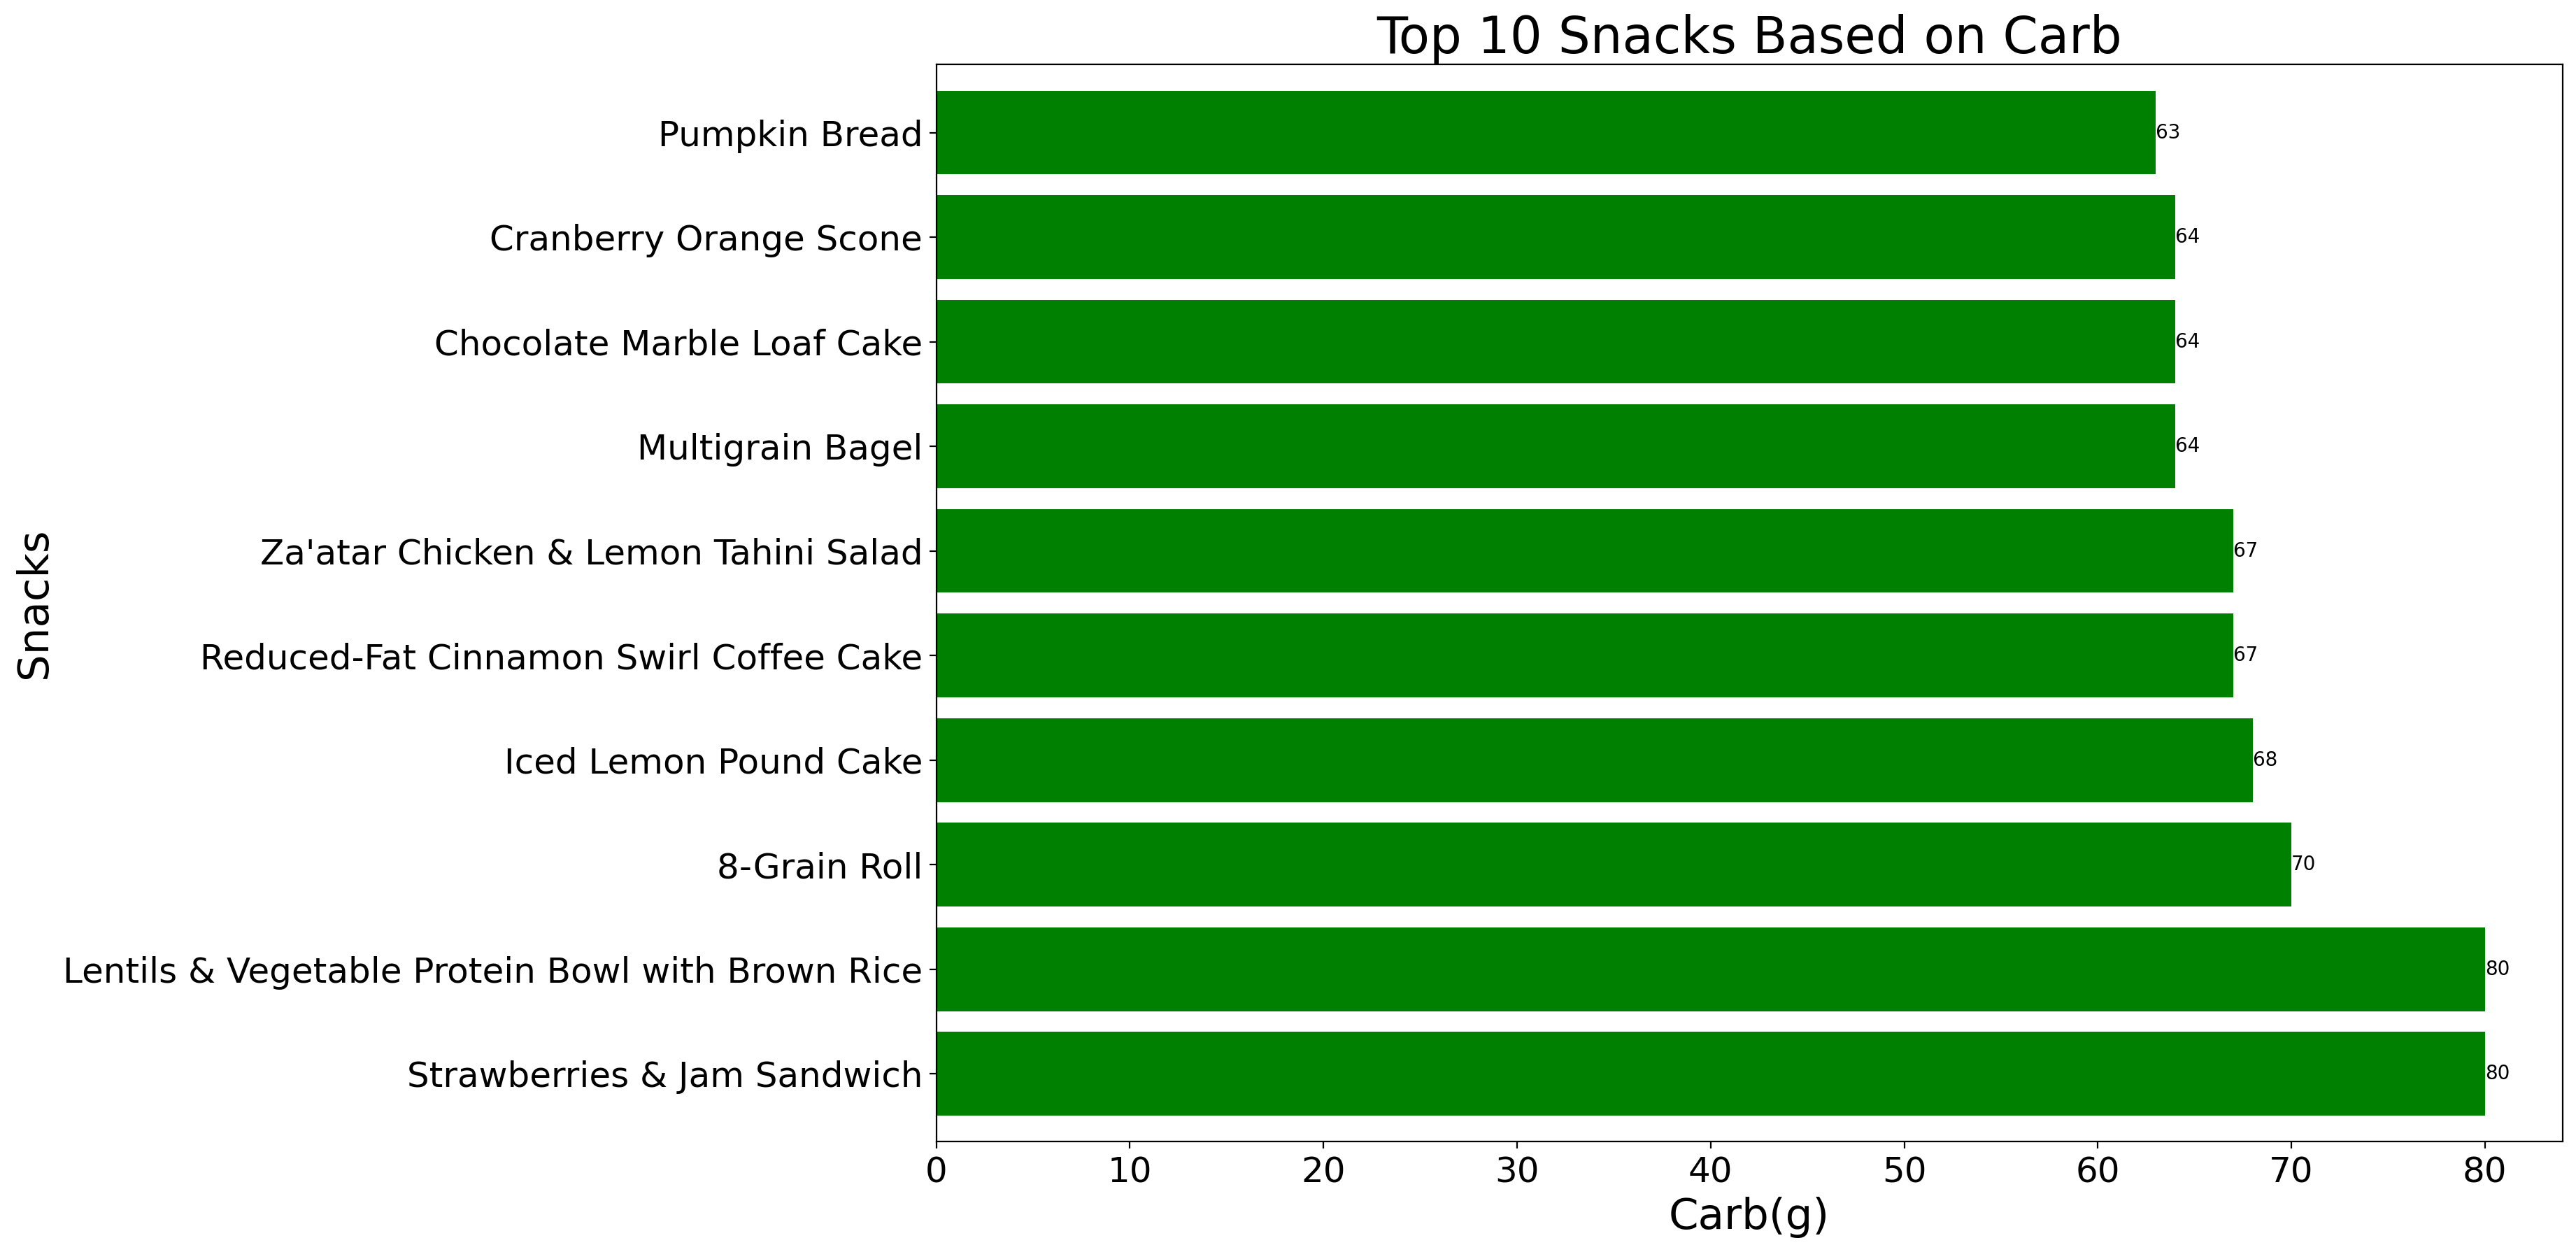

In [54]:
x = df3.groupby(['Snacks']).max()[' Carb. (g)'].sort_values(ascending=False)[:10] 
plt.figure(figsize = (15,10), dpi = 200)
ax = x.plot(kind = 'barh', width = 0.8,color = 'g' )
for bars in ax.containers :
    ax.bar_label(bars)
    
ax.set_xlabel('Carb(g)', size = 22)    
ax.set_ylabel('Snacks', size = 22)    
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.title("Top 10 Snacks Based on Carb", size = 26)
plt.show()

<b> Highest Carb of the Snacks is 'Strawberries $ Jam Sandwich' , which is 80

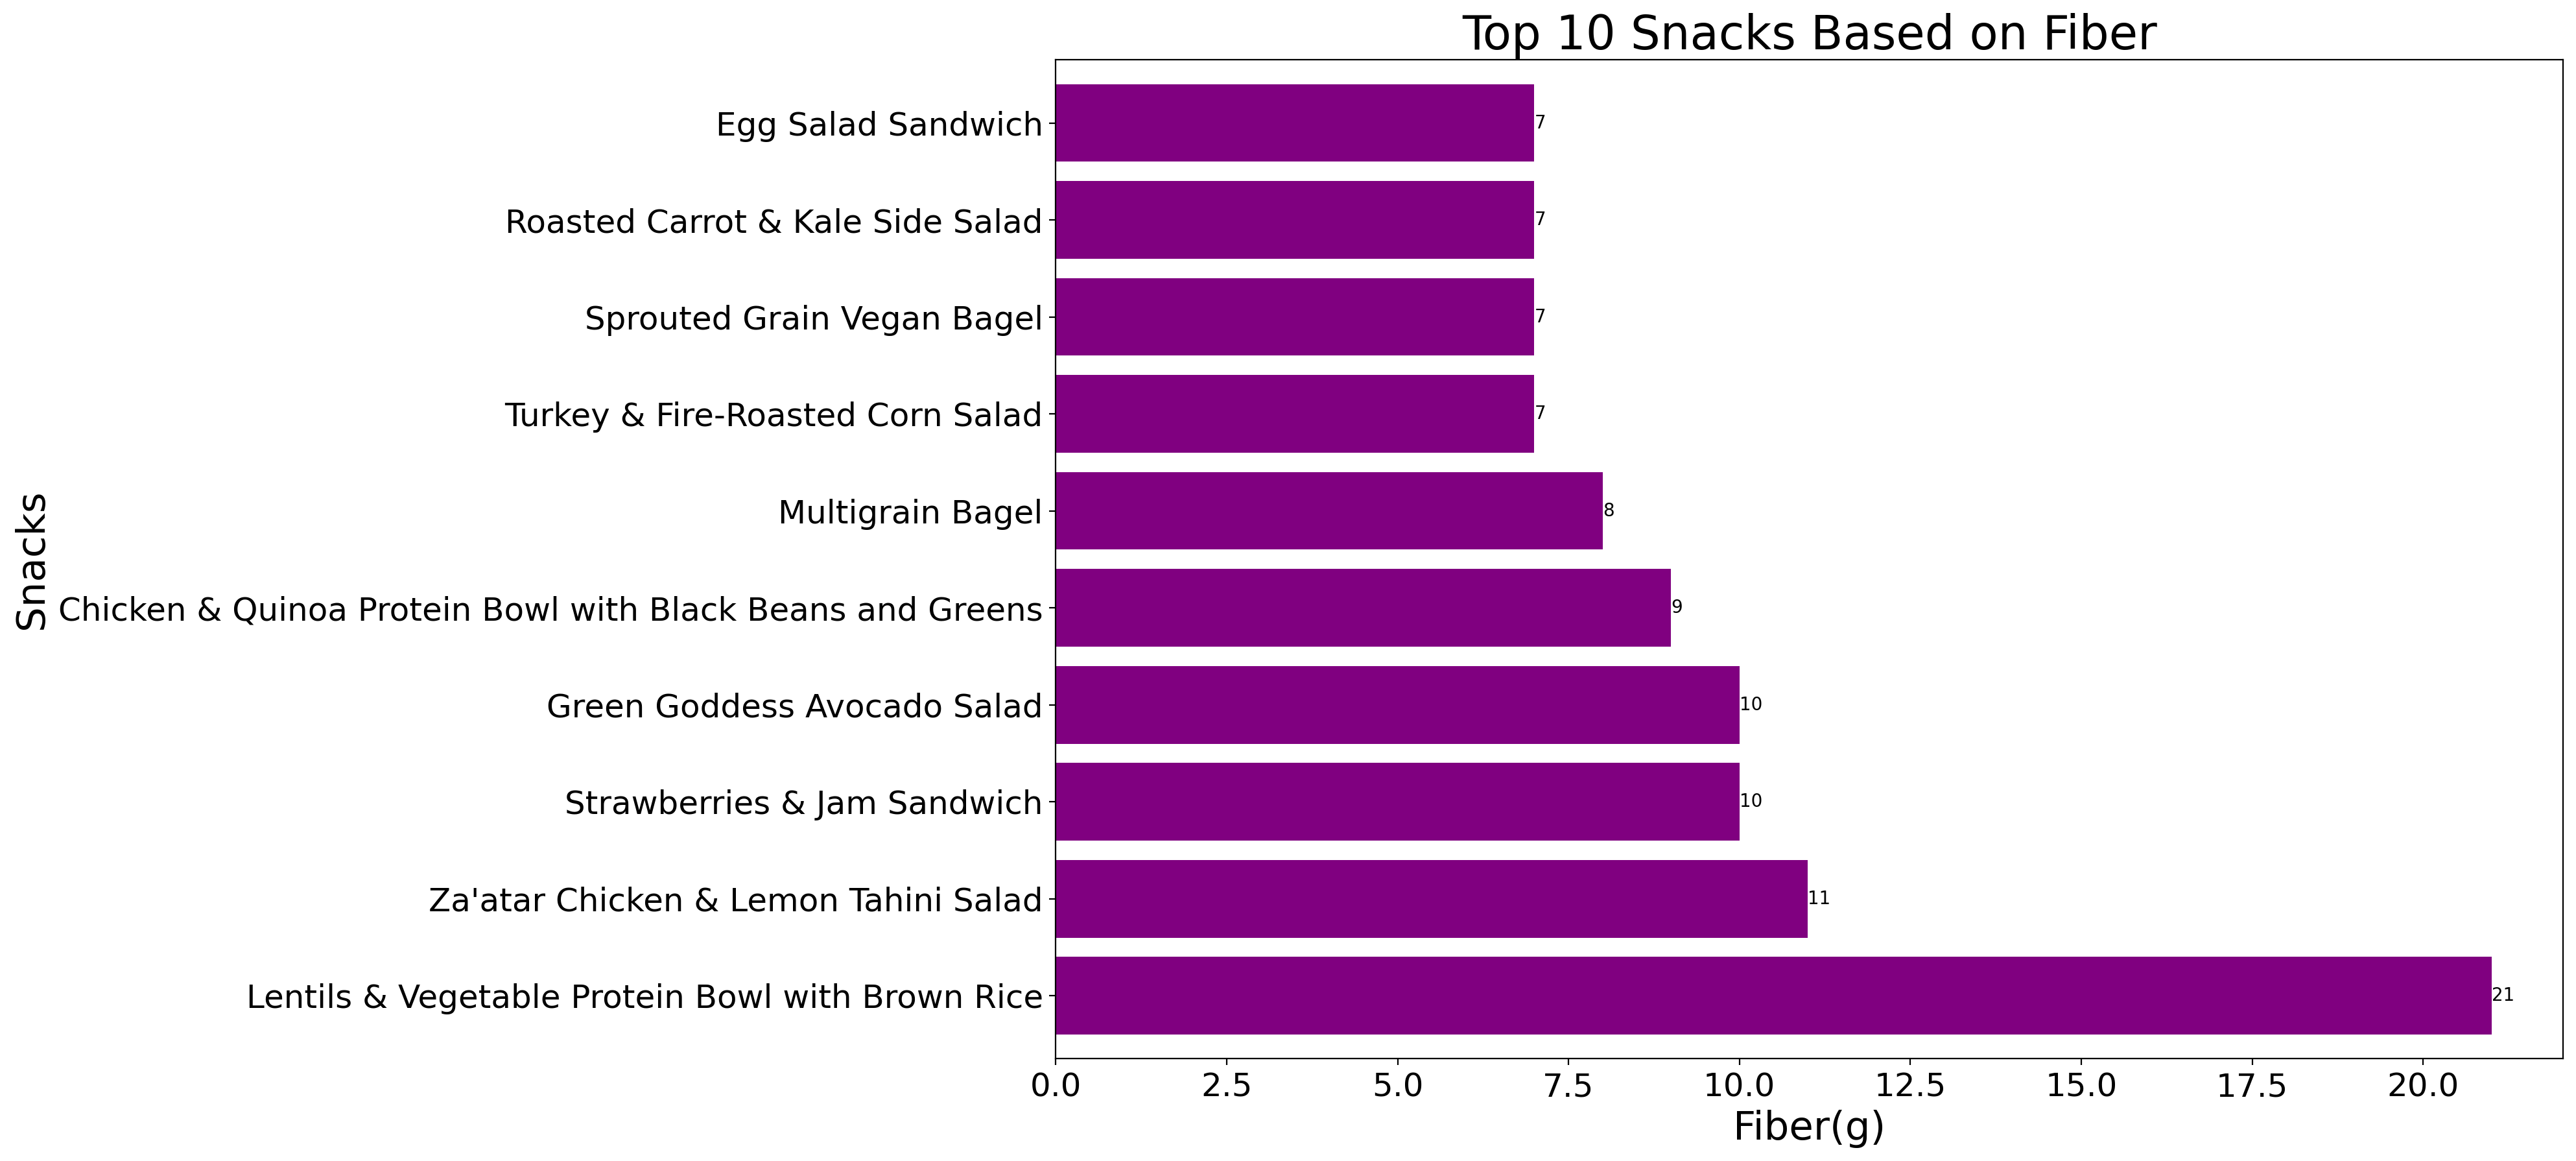

In [55]:
x = df3.groupby(['Snacks']).max()[' Fiber (g)'].sort_values(ascending=False)[:10] 
plt.figure(figsize = (15,10), dpi = 200)
ax = x.plot(kind = 'barh', width = 0.8,color = 'purple' )
for bars in ax.containers :
    ax.bar_label(bars)
    
ax.set_xlabel('Fiber(g)', size = 22)    
ax.set_ylabel('Snacks', size = 22)    
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.title("Top 10 Snacks Based on Fiber", size = 26)
plt.show()

<b> Highest Fiber of the Snacks is 'Lentils $ Vegetable Protein Bowl Rice' , which is 20

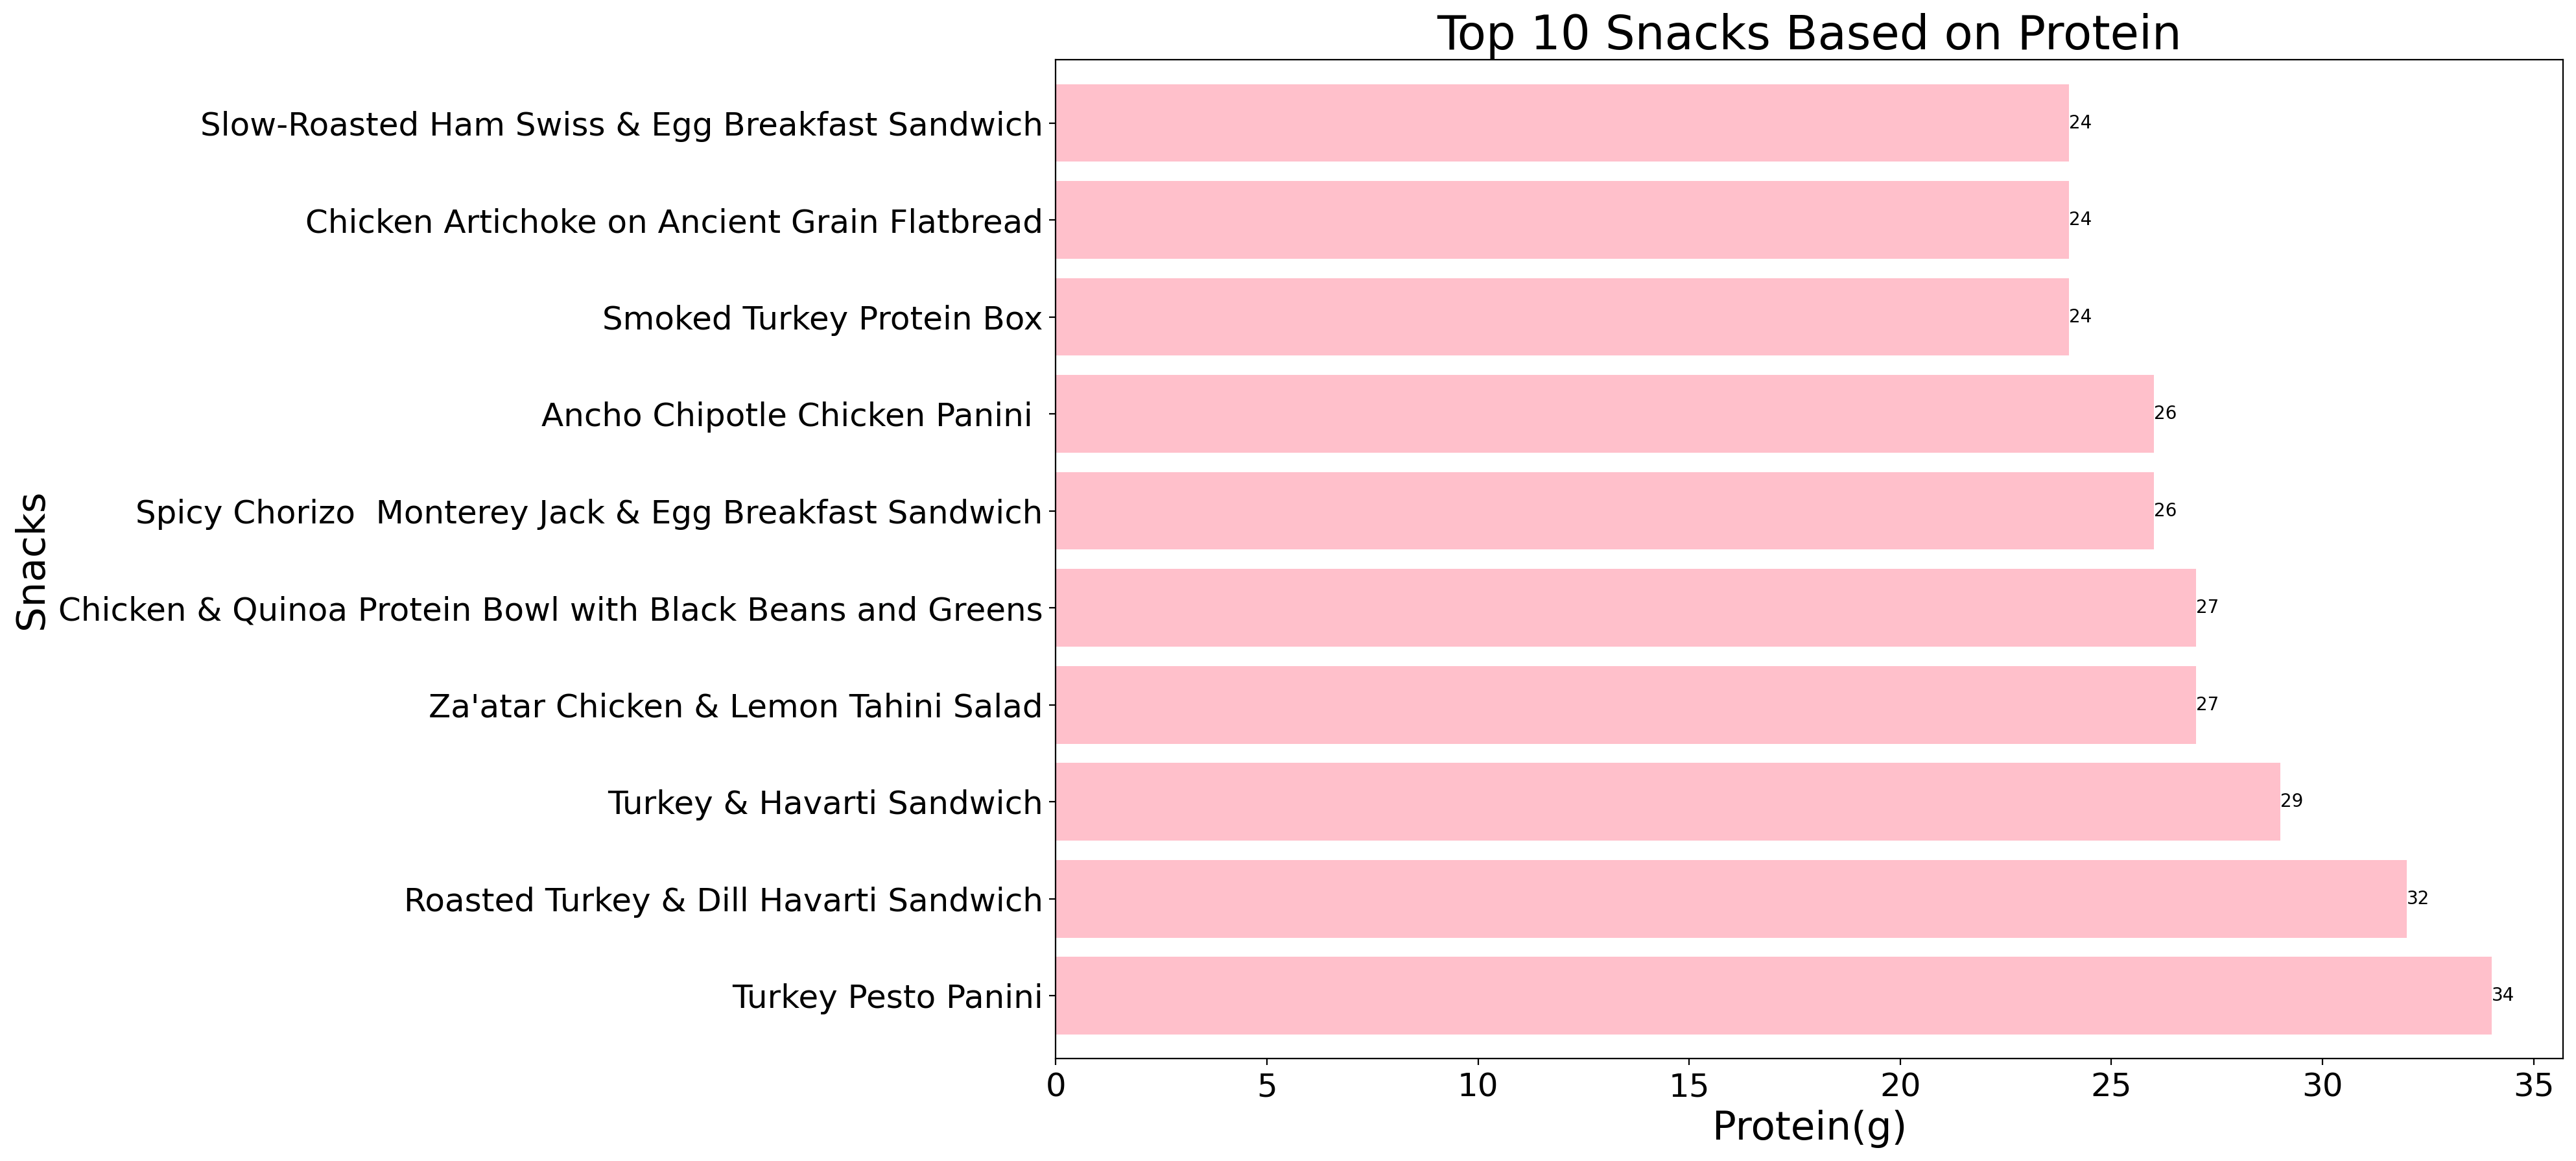

In [56]:
x = df3.groupby(['Snacks']).max()[' Protein (g)'].sort_values(ascending=False)[:10] 
plt.figure(figsize = (15,10), dpi = 200)
ax = x.plot(kind = 'barh', width = 0.8,color = 'pink' )
for bars in ax.containers :
    ax.bar_label(bars)
    
ax.set_xlabel('Protein(g)', size = 22)    
ax.set_ylabel('Snacks', size = 22)    
plt.xticks(fontsize = 18)
plt.yticks(fontsize = 18)
plt.title("Top 10 Snacks Based on Protein", size = 26)
plt.show()

<b> Highest Calories of the Snacks is 'Turkey Pesto Panini' , which is 35

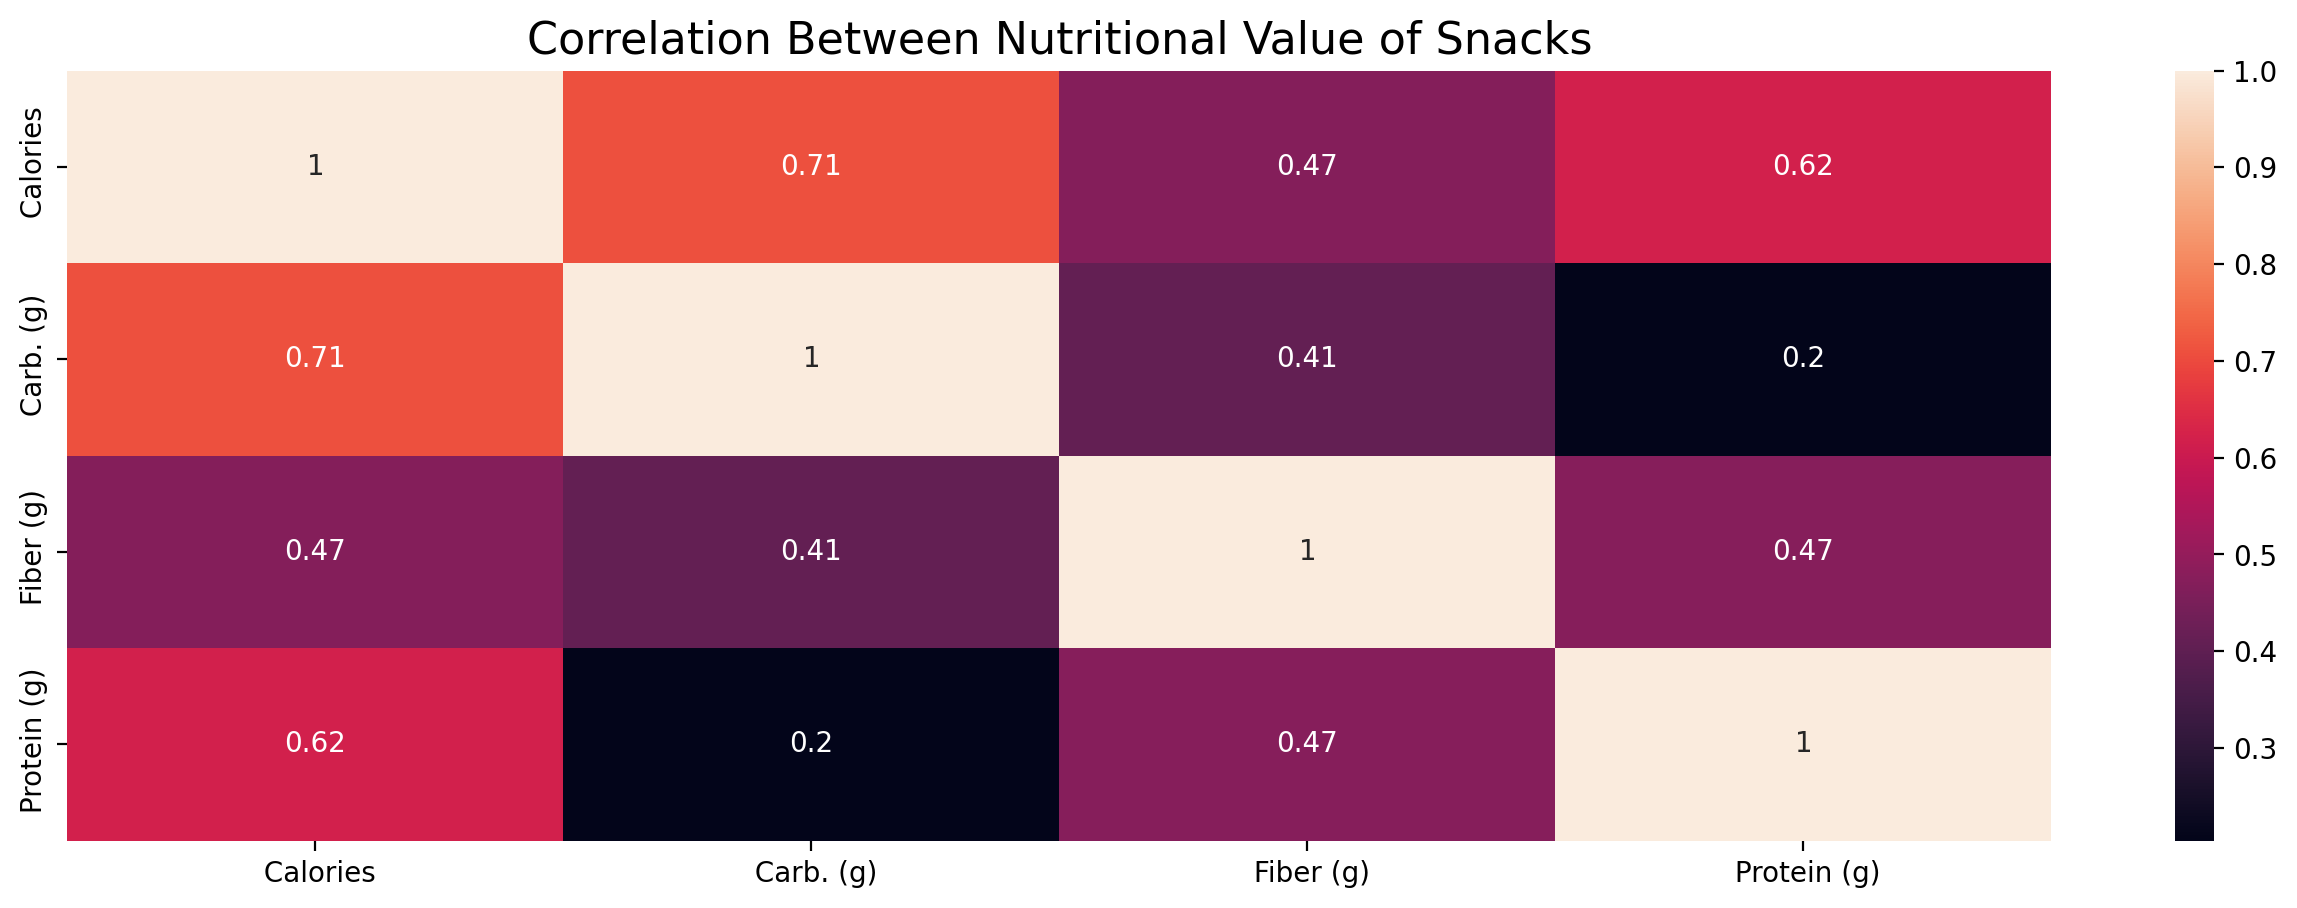

In [57]:
plt.figure(figsize = (16,5), dpi = 200)
sns.heatmap(df3[[' Calories',' Carb. (g)',' Fiber (g)',' Protein (g)']].corr(), annot = True)
plt.title('Correlation Between Nutritional Value of Snacks', size = 16)
plt.show()

<b> In Heatmap Shows, Correlation Between Calories, Carb, Fiber and Protein

### Conclusion

- we can see that Chocalate Smoothie, Hot Choclate, Strawberry Smoothie, Caffe Mocha is High in Calories, which is 320, 320, 300, 290 respectively. It is also High in Protein, Carb and Fibre which is good for health.

- According to (Beverage_category, Beverage, Beverage_prep), Highest number of Dietary Fibre in (Smoothies, Strawberry Banana Smoothie, soymilk) which is 8g But when Dietary Fibre is high, Trans Fat is low beacause trans fatty acid raises bad cholestrol. In Trans Fat (Signature Espresso Drinks(White Chocolate Mocha without whipped cream), 2% Milk) is highest which is 9g. Also this Beverage menu is 3rd highest in cholestrol which is 80mg. (Signature Espresso Drinks(White Chocolate Mocha without whipped cream), 2% Milk) is also highest in Calories which is 510. In Carbohydrate, this beverage menu is the 4th highest which is 330g and it leads to wegiht gain, Poor metabolic health and an increased risk of heart disease. Overall, (Signature Espresso Drinks(White Chocolate Mocha without whipped cream), 2% Milk) is not good for health. so it should be removed in the list of Beverage menu.

- 'Za'atar Chicken and lemon Tahini Salad' is high in Calories which is 570. It is also High in Protein, Carb and Fibre which is good for health